# Model 3 — 3-Layer XGBoost + Sentiment (Weekly Frequency)

**Architecture: 3-Layer Feature Design**

| Layer | Features | Source | Rationale |
|---|---|---|---|
| **Layer 1 — Hard Data** | Oil, Fed Funds, CPI, GDP, Exchange Rate | FRED + World Bank | Lagging macro fundamentals |
| **Layer 2 — Sentiment Proxy** | VIX level, Thailand Uncertainty, Global Uncertainty, US Consumer Sentiment | FRED | Market-derived fear/greed indicators |
| **Layer 3 — News Sentiment** | Monthly compound score (VADER) from RSS feeds | news_sentiment.csv | Text-based leading indicator |

**Data: Weekly frequency (W-FRI)**

| Period | Rows | vs Monthly baseline |
|---|---|---|
| Training 2000–2019 | ~830 weeks (after dropna) | **+4.6× more data** |
| Test 2020–2025 | ~310 weeks | — |

**Targets:** SET weekly return · Gold weekly return · USD/THB weekly return

**Key anti-overfit measures:**
- Weekly data → ~4.6× more training samples → less overfitting
- Feature selection: top 18 by Spearman correlation (vs 63 unfiltered)
- Strong regularization: `max_depth ≤ 4`, `min_child_weight 5–30`, `reg_alpha/lambda 0.1–10`
- Optuna tuning with TimeSeriesSplit CV

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110

RAW_DIR  = Path('../../data/raw')
PROC_DIR = Path('../../data/processed')

# Weekly targets (suffix _ret_w instead of _ret_m)
TARGETS = {
    'SET_index_ret_w': 'SET Index (Weekly Return)',
    'gold_ret_w':      'Gold (Weekly Return)',
    'USD_THB_ret_w':   'USD/THB (Weekly Return)',
}

TRAIN_END  = '2019-12-31'
TEST_START = '2020-01-01'
print('Setup complete — using unified_weekly.csv')

Setup complete — using unified_weekly.csv


/home/ppt/notebook/Thailand-Economic-Analysis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## Step 1 — Layer 3: Aggregate News Sentiment → Monthly Score

Parse `news_sentiment.csv` → resample to monthly → weighted VADER compound score.

The pipeline handles sparse data gracefully: months with no news get `NaN` (filled with 0 = neutral).

In [2]:
# ── Load all news sources: Bangkok Post RSS + GDELT historical ───────────────
news_parts = []

# 1. Bangkok Post RSS (short history, authoritative)
try:
    bp = pd.read_csv(RAW_DIR / 'news_sentiment.csv')
    bp['source'] = bp.get('source', pd.Series('bangkok_post', index=bp.index))
    news_parts.append(bp)
    print(f'Bangkok Post: {len(bp)} articles')
except FileNotFoundError:
    print('[skip] news_sentiment.csv not found')

# 2. GDELT historical (2015→2025, large dataset)
gdelt_path = RAW_DIR / 'news_gdelt.csv'
if gdelt_path.exists():
    gd = pd.read_csv(gdelt_path)
    news_parts.append(gd)
    print(f'GDELT       : {len(gd)} articles')
else:
    print('[skip] news_gdelt.csv not found — run: python src/fetch_data.py')

news_raw = pd.concat(news_parts, ignore_index=True) if news_parts else pd.DataFrame()

if news_raw.empty:
    print('[warn] No news data available — sentiment features will be zero')
    monthly_news = pd.DataFrame(index=pd.date_range('2000-09-01', '2025-12-31', freq='W-FRI'))
    for col in ['news_sentiment_score', 'news_article_count', 'news_power_words',
                'news_sent_3w_ma', 'news_sent_8w_ma', 'news_sent_momentum', 'news_sent_z']:
        monthly_news[col] = 0.0
else:
    news_raw['published'] = pd.to_datetime(news_raw['published'], utc=True, errors='coerce')
    news_raw = news_raw.dropna(subset=['published']).set_index('published').sort_index()
    news_raw.index = news_raw.index.tz_localize(None)

    score_col = 'weighted_compound' if 'weighted_compound' in news_raw.columns else 'compound'
    news_raw['_score'] = news_raw[score_col].fillna(0)

    print(f'\nCombined news: {len(news_raw)} articles  |  score col: "{score_col}"')
    print(f'Date range   : {news_raw.index.min().date()} → {news_raw.index.max().date()}')
    if 'source' in news_raw.columns:
        print(news_raw['source'].value_counts().to_string())

    # Importance-weighted weekly aggregation
    if 'importance' in news_raw.columns and 'weighted_compound' in news_raw.columns:
        def _wtd_mean(g):
            w = g['importance'].fillna(1.0)
            s = g['weighted_compound']
            return (s * w).sum() / w.sum() if w.sum() > 0 else 0.0
        weekly_score = news_raw.resample('W-FRI').apply(_wtd_mean).rename('news_sentiment_score')
    else:
        weekly_score = news_raw['_score'].resample('W-FRI').mean().rename('news_sentiment_score')

    weekly_count = news_raw['_score'].resample('W-FRI').count().rename('news_article_count')
    weekly_pwc   = (news_raw['power_word_count'].resample('W-FRI').sum()
                    if 'power_word_count' in news_raw.columns
                    else pd.Series(0, index=weekly_score.index)).rename('news_power_words')

    monthly_news = pd.concat([weekly_score, weekly_count, weekly_pwc], axis=1)

    # Sentiment flow features
    monthly_news['news_sent_3w_ma'] = monthly_news['news_sentiment_score'].rolling(3, min_periods=1).mean()
    monthly_news['news_sent_8w_ma'] = monthly_news['news_sentiment_score'].rolling(8, min_periods=2).mean()
    monthly_news['news_sent_momentum'] = (monthly_news['news_sentiment_score']
                                          - monthly_news['news_sent_3w_ma'].shift(1))
    _sent_mean = monthly_news['news_sentiment_score'].rolling(26, min_periods=4).mean()
    _sent_std  = monthly_news['news_sentiment_score'].rolling(26, min_periods=4).std().clip(lower=0.01)
    monthly_news['news_sent_z'] = (monthly_news['news_sentiment_score'] - _sent_mean) / _sent_std

    for col in monthly_news.columns:
        monthly_news[col] = monthly_news[col].ffill(limit=2).fillna(0)

    print(f'\nWeekly news features : {monthly_news.shape}')
    print(f'Weeks with articles  : {(monthly_news["news_article_count"] > 0).sum()}')
    active_wks = monthly_news[monthly_news["news_article_count"] > 0]
    if len(active_wks):
        print(active_wks[['news_sentiment_score','news_article_count',
                           'news_sent_z','news_sent_momentum']].tail(10).to_string())


Bangkok Post: 10 articles
[skip] news_gdelt.csv not found — run: python src/fetch_data.py

Combined news: 10 articles  |  score col: "compound"
Date range   : 2026-05-08 → 2026-05-08
source
bangkok_post    10

Weekly news features : (1, 7)
Weeks with articles  : 1
            news_sentiment_score  news_article_count  news_sent_z  news_sent_momentum
published                                                                            
2026-05-08               0.00745                  10          0.0                 0.0


---
## Step 2 — Feature Engineering: All 3 Layers

Build the full feature matrix:
- **Layer 1**: Macro fundamentals (raw levels + MoM change)
- **Layer 2**: Sentiment proxies (VIX level, uncertainty indices, consumer confidence)
- **Layer 3**: News sentiment (VADER compound score, article volume)
- **Derived**: Lag features (1m, 3m, 6m), rolling momentum + volatility, regime flag

In [3]:
base = pd.read_csv(PROC_DIR / 'unified_weekly.csv', index_col=0, parse_dates=True)

# ── LAYER 1: Hard Data (macro fundamentals + global market signals) ────────
L1_COLS = [
    'oil_ret_w',              # Oil price weekly return
    'us_fed_funds_rate',      # US interest rate level
    'us_cpi_monthly',         # US inflation level (for real yield derivation)
    'us_unemployment',        # US unemployment level
    'us_industrial_prod',     # US industrial output
    'th_exchange_rate_real',  # THB real exchange rate
    'th_us_imports',          # Thailand-US trade flow
    'th_property_prices',     # Thailand property market
    'lending_rate_annual',    # Thailand domestic lending rate
    'gdp_growth_annual',      # Thailand GDP growth
    # Global market signals (leading indicators for emerging markets)
    'sp500_ret_w',            # US equity direction
    'nasdaq_ret_w',           # Risk-on/off signal
    'us_10yr_treasury_ret_w', # Bond market (risk sentiment)
    'us_10yr_treasury_price', # 10Y yield level — for real yield computation
    'us_2yr_treasury_price',  # 3M T-Bill yield — for yield curve (10Y−3M) computation
    # USD strength — driver of Gold and USD/THB
    'dxy_ret_w',              # US Dollar Index weekly return
    'dxy_price',              # DXY level — for z-score normalization
]

# ── LAYER 2: Sentiment Proxy (market-derived fear/greed) ──────────────────
L2_COLS = [
    'vix_price',              # VIX = "fear gauge" (level matters more than return)
    'th_uncertainty',         # Thailand Economic Policy Uncertainty
    'global_uncertainty',     # Global Economic Uncertainty Index
    'us_consumer_sentiment',  # US Consumer Confidence (leading indicator)
]

# ── Cross-market daily lag features (timezone lead effect) ────────────────
# S&P500 Thu close = 4am Bangkok Fri → before SET Fri open (9:30am)
# These are GENUINE leading indicators, not leaky features.
DAILY_LAG_COLS = [c for c in base.columns if '_ret_d_lag' in c]

# Keep only columns that exist in the weekly dataset
L1_COLS = [c for c in L1_COLS if c in base.columns]
L2_COLS = [c for c in L2_COLS if c in base.columns]

all_input_cols = list(set(L1_COLS + L2_COLS + DAILY_LAG_COLS + list(TARGETS.keys())))
df = base[[c for c in all_input_cols if c in base.columns]].copy()

# MoM-style change for level FRED series
for col in ['us_fed_funds_rate', 'us_cpi_monthly', 'us_unemployment',
            'us_industrial_prod', 'th_exchange_rate_real', 'th_us_imports',
            'th_property_prices', 'lending_rate_annual', 'gdp_growth_annual']:
    if col in df.columns:
        df[f'{col}_chg'] = df[col].pct_change().replace([np.inf, -np.inf], np.nan)

# Z-score normalize VIX and uncertainty (remove level drift)
for col in L2_COLS:
    df[f'{col}_z'] = (df[col] - df[col].expanding().mean()) / df[col].expanding().std()

# ── DERIVED: Lag features — 1w, 4w (≈1m), 13w (≈3m) ─────────────────────
KEY_SIGNALS = ['sp500_ret_w', 'nasdaq_ret_w', 'vix_price', 'gold_ret_w',
               'USD_THB_ret_w', 'us_consumer_sentiment', 'th_uncertainty',
               'dxy_ret_w']
KEY_SIGNALS = [c for c in KEY_SIGNALS if c in df.columns]

for col in KEY_SIGNALS:
    for lag in [1, 4, 13]:   # 1 week, ~1 month, ~3 months
        df[f'{col}_lag{lag}w'] = df[col].shift(lag)

# ── DERIVED: Rolling momentum + volatility — 4w (≈1m), 13w (≈3m) ─────────
for target_col in TARGETS:
    if target_col not in df.columns:
        continue
    for window in [4, 13]:
        df[f'{target_col}_mom{window}w'] = df[target_col].rolling(window).mean().shift(1)
        df[f'{target_col}_vol{window}w'] = df[target_col].rolling(window).std().shift(1)

# ── DERIVED: Regime detection via VIX percentile ─────────────────────────
df['vix_pct'] = df['vix_price'].rank(pct=True)
df['regime']  = pd.cut(df['vix_pct'], bins=[0, 0.33, 0.67, 1.0],
                        labels=[0, 1, 2]).astype(float)

# Merge news sentiment — include all sentiment flow columns
news_cols = ['news_sentiment_score', 'news_article_count', 'news_power_words',
             'news_sent_3w_ma', 'news_sent_8w_ma', 'news_sent_momentum', 'news_sent_z']
news_cols_avail = [c for c in news_cols if c in monthly_news.columns]
df = df.merge(monthly_news[news_cols_avail],
              left_index=True, right_index=True, how='left')
for col in news_cols_avail:
    df[col] = df[col].fillna(0)

print(f'Full feature matrix: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Date range: {df.index[0].date()} → {df.index[-1].date()}')
print(f'Daily lag cols: {DAILY_LAG_COLS}')



Full feature matrix: 1322 rows x 92 columns
Date range: 2000-09-01 → 2025-12-26
Daily lag cols: ['sp500_ret_d_lag1', 'sp500_ret_d_lag2', 'nasdaq_ret_d_lag1', 'nasdaq_ret_d_lag2', 'oil_ret_d_lag1', 'oil_ret_d_lag2', 'dxy_ret_d_lag1', 'dxy_ret_d_lag2', 'USD_THB_ret_d_lag1', 'USD_THB_ret_d_lag2']


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOCK A — Regime Binary Dummies
# ──────────────────────────────────────────────────────────────────────────────
# ทำไมต้องแปลง regime (0/1/2) → 3 binary columns?
# XGBoost splits แบบ "feature > threshold" — ถ้าใช้ 0/1/2 ตรงๆ model จะ
# เรียนรู้ split ที่ regime > 0.5 เท่านั้น แต่ไม่สามารถแยก crisis ออกได้อิสระ
# Binary dummies ให้แต่ละ regime มี dimension ของตัวเอง
# ══════════════════════════════════════════════════════════════════════════════

df['is_bull']   = (df['regime'] == 0).astype(float)   # VIX ≤ 33rd pct
df['is_normal'] = (df['regime'] == 1).astype(float)   # VIX 33–67th pct
df['is_crisis'] = (df['regime'] == 2).astype(float)   # VIX ≥ 67th pct

# ── BLOCK B: Signal × Regime Interaction Terms ────────────────────────────────
# ทฤษฎี Regime-Dependent Signal Strength:
#   signal × is_bull   → signal "active" เฉพาะใน bull market
#   signal × is_crisis → signal "active" เฉพาะใน crisis
# XGBoost เรียนรู้ coefficient ต่างกันตาม regime โดยไม่ต้องแยก model
# (แยก model = เหลือ data แค่ 1/3 — ไม่คุ้ม)
# ══════════════════════════════════════════════════════════════════════════════

INTERACTION_MAP = {
    'sp500_ret_w':             ['is_bull', 'is_normal', 'is_crisis'],
    'vix_price_z':             ['is_normal', 'is_crisis'],
    'gold_ret_w':              ['is_bull',  'is_crisis'],
    'us_consumer_sentiment_z': ['is_bull',  'is_normal'],
    'oil_ret_w':               ['is_bull',  'is_crisis'],
    'us_10yr_treasury_ret_w':  ['is_normal','is_crisis'],
    'nasdaq_ret_w':            ['is_bull',  'is_normal'],
    'global_uncertainty_z':    ['is_normal','is_crisis'],
    'dxy_ret_w':               ['is_bull',  'is_normal', 'is_crisis'],  # DXY × all regimes
}

for signal, regimes in INTERACTION_MAP.items():
    if signal not in df.columns:
        continue
    for r in regimes:
        df[f'{signal}__x__{r}'] = df[signal] * df[r]

n_ix = sum(len(v) for k, v in INTERACTION_MAP.items() if k in df.columns)
print(f'[B] Interaction terms: {n_ix}')

# ── BLOCK C: Long-Horizon Momentum ────────────────────────────────────────────
# ทฤษฎี: Momentum Factor (Jegadeesh & Titman 1993)
# หุ้นที่ขึ้นใน 6–12 เดือนที่แล้วมักยังขึ้นต่ออีก 1–6 เดือน (ใน normal market)
# 26w = 6m intermediate momentum (sweet spot), 52w = 12m annual momentum
# ══════════════════════════════════════════════════════════════════════════════

MOMENTUM_COLS = [c for c in ['SET_index_ret_w', 'gold_ret_w', 'USD_THB_ret_w',
                              'sp500_ret_w', 'oil_ret_w', 'nasdaq_ret_w', 'dxy_ret_w']
                 if c in df.columns]
for col in MOMENTUM_COLS:
    df[f'{col}_mom26w'] = df[col].rolling(26).mean().shift(1)
    df[f'{col}_mom52w'] = df[col].rolling(52).mean().shift(1)

print(f'[C] Long momentum: {len(MOMENTUM_COLS)*2} features (26w + 52w × {len(MOMENTUM_COLS)} assets)')

# ── BLOCK D: Interest Rate Carry Signal ───────────────────────────────────────
# ทฤษฎี: Carry Trade (UIP)
# US rate > TH rate → ทุนไหลเข้า USD → THB อ่อน → USD/THB สูง
# ใน crisis carry trade ล้ม — ดังนั้น rate_carry × is_normal คือ signal ที่ดีที่สุด
# ══════════════════════════════════════════════════════════════════════════════

if 'us_fed_funds_rate' in df.columns and 'lending_rate_annual' in df.columns:
    df['rate_carry']                  = df['us_fed_funds_rate'] - df['lending_rate_annual']
    df['rate_carry_chg']              = df['rate_carry'].diff(4).shift(1)
    df['rate_carry__x__is_normal']    = df['rate_carry'] * df['is_normal']
    df['rate_carry__x__is_bull']      = df['rate_carry'] * df['is_bull']
    print('[D] Rate carry: 4 features')
else:
    print('[D] Rate carry: skipped')

# ── BLOCK E: Seasonal Encoding (sin/cos Fourier) ──────────────────────────────
# ทำไม sin/cos ดีกว่า one-hot (12 dummies)?
#   1. ประหยัด dimension: 2 features แทน 12
#   2. Cyclical continuity: ธ.ค.→ม.ค. อยู่ใกล้กันใน circular space
#   3. Smooth transitions: ไม่มีขอบแหลมระหว่างเดือน
# ══════════════════════════════════════════════════════════════════════════════

_month = df.index.month.astype(float)
_week  = df.index.isocalendar().week.astype(float)

df['month_sin'] = np.sin(2 * np.pi * _month / 12)
df['month_cos'] = np.cos(2 * np.pi * _month / 12)
df['week_sin']  = np.sin(2 * np.pi * _week  / 52)
df['week_cos']  = np.cos(2 * np.pi * _week  / 52)
print('[E] Seasonal encoding: 4 features')

# ── BLOCK F: 52-Week Price Position (George & Hwang 2004) ─────────────────────
# % from 52w high: -3% = ใกล้ high = momentum signal; -35% = crisis zone
# 52w range pos:    0 = annual low (oversold);          1 = annual high (overbought)
# ══════════════════════════════════════════════════════════════════════════════

_price_map = {'SET_index': 'SET_index_price', 'gold': 'gold_price',
              'USD_THB': 'USD_THB_price', 'dxy': 'dxy_price'}

for asset, pcol in _price_map.items():
    if pcol not in base.columns:
        continue
    px = base[pcol].reindex(df.index)
    hi = px.rolling(52).max()
    lo = px.rolling(52).min()
    rng = (hi - lo).replace(0, np.nan)
    df[f'{asset}_pct_from_52w_high'] = ((px - hi) / hi).shift(1)
    df[f'{asset}_52w_range_pos']     = ((px - lo) / rng).shift(1).clip(0, 1)

n_52w = sum(1 for pcol in _price_map.values() if pcol in base.columns) * 2
print(f'[F] 52-week position: {n_52w} features')

# ── BLOCK G: VIX Velocity & Acceleration ──────────────────────────────────────
# VIX Velocity    = pct_change(4w) — VIX กำลังเร่งขึ้น/ลดลงเร็วแค่ไหน
# VIX Acceleration = 2nd derivative — crisis peak ผ่านไปหรือยัง
# VIX Pullback    = vix_z × (-velocity) — "VIX สูง + กำลังลด" = relief rally signal
# ══════════════════════════════════════════════════════════════════════════════

df['vix_velocity']     = df['vix_price'].pct_change(4).shift(1)
df['vix_acceleration'] = df['vix_velocity'].diff(4).shift(1)
df['vix_pullback']     = (df['vix_price_z'].shift(1) * (-df['vix_velocity'].shift(1))).clip(-5, 5)
print('[G] VIX velocity/accel/pullback: 3 features')

# ══════════════════════════════════════════════════════════════════════════════
# BLOCK H — Real Yield · Yield Curve · DXY  (Structural Macro Drivers)
# ══════════════════════════════════════════════════════════════════════════════

# ── H1: REAL YIELD ⭐⭐⭐⭐⭐ — driver หลักของ Gold ────────────────────────────
# Real Yield = Nominal 10Y Yield (%) − CPI YoY Inflation (%)
#
# ทองไม่มีดอกเบี้ย (zero coupon asset)
#   Real yield ↑  → bond ให้ผลตอบแทนที่แท้จริงสูงกว่า → ถือ bond คุ้มกว่า → Gold ↓
#   Real yield ↓/ลบ → bond แพ้เงินเฟ้อ → ทองเป็น inflation hedge ที่ดีกว่า → Gold ↑
#
# Note: us_10yr_treasury_price ใน dataset = yield level (%) จาก ^TNX
#       ค่าเช่น 4.39 = 4.39% nominal yield ✓ (ไม่ใช่ bond price)
# Ref: Erb & Harvey (2013), World Gold Council
# ══════════════════════════════════════════════════════════════════════════════

if 'us_10yr_treasury_price' in df.columns and 'us_cpi_monthly' in df.columns:
    cpi_yoy = df['us_cpi_monthly'].pct_change(52) * 100    # YoY inflation (%)
    df['real_yield']       = (df['us_10yr_treasury_price'] - cpi_yoy).shift(1)
    df['real_yield_chg4w'] = df['real_yield'].diff(4)
    df['real_yield_z']     = ((df['real_yield'] - df['real_yield'].expanding().mean())
                              / df['real_yield'].expanding().std())
    print('[H1] Real yield: 3 features')
else:
    print('[H1] Real yield: skipped')

# ── H2: YIELD CURVE SLOPE (10Y − 3M) ⭐⭐⭐⭐ — Recession Signal ────────────
# yield_curve > 0 = normal (10Y > 3M) → เศรษฐกิจขยายตัว
# yield_curve < 0 = inverted → ตลาดคาด Fed จะลดดอกเบี้ย → มักนำ recession 6–18m
#
# NY Fed ใช้ 10Y−3M spread เป็น official recession probability model
# us_2yr_treasury_price ใน dataset = ^IRX (13-week T-Bill yield) = short end ✓
#
# ผลต่อ assets:
#   Inverted (< 0) → SET ↓ (recession fear)
#                 → Gold ↑ (safe haven + Fed cut expectation)
#                 → USD/THB ↑ (risk-off → USD strength)
# ══════════════════════════════════════════════════════════════════════════════

if 'us_10yr_treasury_price' in df.columns and 'us_2yr_treasury_price' in df.columns:
    df['yield_curve']       = (df['us_10yr_treasury_price'] - df['us_2yr_treasury_price']).shift(1)
    df['yield_curve_chg4w'] = df['yield_curve'].diff(4)
    df['yield_curve_inv']   = (df['yield_curve'] < 0).astype(float)  # inverted = recession warning
    print('[H2] Yield curve (10Y−3M): 3 features')
else:
    print('[H2] Yield curve: skipped')

# ── H3: DXY FEATURES ⭐⭐⭐⭐⭐ — USD Strength Driver ──────────────────────────
# DXY = EUR(57.6%) + JPY(13.6%) + GBP(11.9%) + CAD(9.1%) + SEK(4.2%) + CHF(3.6%)
#
# ความสัมพันธ์:
#   DXY ↑ → Gold ↓  (ทองราคา USD — USD แข็ง → ทองแพงขึ้นในสายตาคนอื่น → demand ลด)
#   DXY ↑ → USD/THB ↑ (USD แข็ง → THB อ่อน)
#   DXY ↑ → SET ↓   (EM equity โดนกด — capital flows ออก EM ตอน USD แข็ง)
#
# dxy_ret_w × is_crisis: จับ "flight-to-dollar" event ได้
#   ใน crisis ทุกคน rush เข้า USD → DXY แข็งมากผิดปกติ
# ══════════════════════════════════════════════════════════════════════════════

if 'dxy_ret_w' in df.columns:
    df['dxy_mom4w']  = df['dxy_ret_w'].rolling(4).mean().shift(1)
    df['dxy_vol13w'] = df['dxy_ret_w'].rolling(13).std().shift(1)
    df['dxy_z']      = ((df['dxy_price'] - df['dxy_price'].expanding().mean())
                        / df['dxy_price'].expanding().std())
    print('[H3] DXY: 3 additional features (mom4w, vol13w, z-score)')
else:
    print('[H3] DXY: skipped')

# ── Summary ───────────────────────────────────────────────────────────────────
print(f'\nFull df columns now: {df.shape[1]}')


[B] Interaction terms: 20
[C] Long momentum: 14 features (26w + 52w × 7 assets)
[D] Rate carry: 4 features
[E] Seasonal encoding: 4 features
[F] 52-week position: 8 features
[G] VIX velocity/accel/pullback: 3 features
[H1] Real yield: 3 features
[H2] Yield curve (10Y−3M): 3 features
[H3] DXY: 3 additional features (mom4w, vol13w, z-score)

Full df columns now: 157


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOCK I — SET-Specific Advanced Features
# ══════════════════════════════════════════════════════════════════════════════
# SET = "global beta + local noise" EM index
# Key drivers: US overnight return, FX flow, trend regime, seasonality
# ══════════════════════════════════════════════════════════════════════════════

# ── I1: Cross-Market Daily Lag × Regime Interactions (ของโคตรแรง) ────────────
# S&P500 Thursday close → Bangkok Friday 4am → SET opens Friday 9:30am
# In crisis: S&P500 overnight signal is AMPLIFIED for SET (flight-to-safety/risk)
# In bull:   S&P500 overnight signal drives momentum-following behavior

D_LAG_SIGNALS = [c for c in df.columns if '_ret_d_lag' in c]
for sig in D_LAG_SIGNALS:
    for regime in ['is_bull', 'is_crisis']:
        if regime in df.columns:
            df[f'{sig}__x__{regime}'] = df[sig] * df[regime]

n_dlag_ix = len(D_LAG_SIGNALS) * 2
print(f'[I1] Daily lag × regime interactions: {n_dlag_ix} features')

# ── I2: SET Trend Regime (above/below Moving Averages) ───────────────────────
# MA cross signal: when 20w > 52w = golden cross (bullish), < = death cross
# SET_above_ma52w is the "primary bull/bear indicator" — most predictive
# Shift(1) to prevent look-ahead: we know Friday close, apply from next week

if 'SET_index_price' in base.columns:
    set_px = base['SET_index_price'].reindex(df.index)
    ma20 = set_px.rolling(20).mean()
    ma52 = set_px.rolling(52).mean()
    df['set_above_ma20w'] = (set_px > ma20).astype(float).shift(1)
    df['set_above_ma52w'] = (set_px > ma52).astype(float).shift(1)
    df['set_ma_cross']    = (ma20 > ma52).astype(float).shift(1)   # golden/death cross
    print('[I2] SET trend regime: 3 features (above_ma20w, above_ma52w, ma_cross)')
else:
    print('[I2] SET trend regime: skipped (SET_index_price not in base)')

# ── I3: USD/THB Daily Velocity — Foreign Capital Flow Proxy ──────────────────
# Fast USD/THB rise = foreign investors selling Thai assets (capital outflow)
# This captures "hot money" flow that dominates SET on short horizons
# usd_thb_d1_lag1 = daily THB move 1 day before Friday (Thursday's flow signal)

if 'USD_THB_ret_d_lag1' in df.columns:
    # Z-score so the signal is comparable across regimes
    s = df['USD_THB_ret_d_lag1']
    df['usd_thb_d1_z'] = ((s - s.expanding().mean()) / s.expanding().std())
    # Interaction: FX flow signal × crisis (capital flight in crisis is strongest signal)
    df['usd_thb_d1__x__is_crisis'] = df['USD_THB_ret_d_lag1'] * df['is_crisis']
    print('[I3] USD/THB daily velocity: 2 features (z-score + crisis interaction)')
else:
    print('[I3] USD/THB daily velocity: skipped')

# ── I4: Calendar Seasonality — Rebalancing Flow Signals ──────────────────────
# End-of-month / quarter-end: institutional funds rebalance → predictable flow
# Thailand has strong rebalancing effects at month-end (pension, LTF/RMF buying)
# "is_month_last_week" = 1 if the NEXT week belongs to a different month

idx_s = pd.Series(df.index, index=df.index)
next_month = idx_s.shift(-1).dt.month.reindex(df.index)
df['is_month_last_week']   = (next_month != df.index.month).astype(float)
df['is_quarter_last_week'] = (df['is_month_last_week'] *
                               df.index.month.isin([3, 6, 9, 12]).astype(float))
# Month-of-year seasonal dummies (Dec/Jan bonus effect, Songkran dip in April)
df['is_jan']  = (df.index.month == 1).astype(float)
df['is_dec']  = (df.index.month == 12).astype(float)
df['is_april']= (df.index.month == 4).astype(float)  # Songkran low-volume week
print('[I4] Calendar seasonality: 5 features (month_last, quarter_last, jan, dec, april)')

# ── I5: SET Drawdown Depth — Contrarian Mean-Reversion Signal ────────────────
# Deep drawdown (< -20%) → higher probability of bounce
# Mild drawdown (−5%) → often continues (momentum)
# set_pct_from_52w_high is already computed in Block F — add quartile bin here

if 'SET_index_pct_from_52w_high' in df.columns:
    dd = df['SET_index_pct_from_52w_high']
    df['set_deep_drawdown'] = (dd < -0.15).astype(float)  # more than 15% below 52w high
    df['set_near_high']     = (dd > -0.03).astype(float)  # within 3% of 52w high
    print('[I5] SET drawdown regime: 2 features (deep_drawdown, near_high)')
else:
    print('[I5] SET drawdown: skipped')

print(f'\nFull df columns after Block I: {df.shape[1]}')


[I1] Daily lag × regime interactions: 20 features
[I2] SET trend regime: 3 features (above_ma20w, above_ma52w, ma_cross)
[I3] USD/THB daily velocity: 2 features (z-score + crisis interaction)
[I4] Calendar seasonality: 5 features (month_last, quarter_last, jan, dec, april)
[I5] SET drawdown regime: 2 features (deep_drawdown, near_high)

Full df columns after Block I: 189


In [6]:
from scipy.stats import spearmanr

RAW_LEVELS_EXCLUDE = [
    'us_fed_funds_rate', 'us_cpi_monthly', 'us_unemployment', 'us_industrial_prod',
    'th_exchange_rate_real', 'th_us_imports', 'th_property_prices',
    'th_uncertainty', 'global_uncertainty', 'us_consumer_sentiment',
    'rate_carry',
]

EXCLUDE = (
    list(TARGETS.keys())
    + [c for c in base.columns if c.endswith('_price')]
    + ['vix_pct', 'regime']
    + RAW_LEVELS_EXCLUDE
)

ALL_FEATURES = [c for c in df.columns
                if c not in EXCLUDE
                and not c.endswith('_annual')
                and '_annual_chg' not in c]

def get_layer(col):
    if any(x in col for x in ['news_sent', 'news_power']):                   return 'Layer 3 · Sentiment Flow'
    if 'news_' in col:                                                        return 'Layer 3 · News Sentiment'
    if '__x__' in col or col in ('is_bull', 'is_normal', 'is_crisis'):       return 'Layer 4 · Regime Interaction'
    if any(x in col for x in ['vix', 'uncertainty', 'sentiment']):           return 'Layer 2 · Sentiment Proxy'
    if '_ret_d_lag' in col:                                                   return 'Layer 7 · Cross-Market Lag'
    if any(x in col for x in ['lag', 'mom', 'vol']):                         return 'Derived · Lag/Momentum'
    if any(x in col for x in ['carry', 'sin', 'cos', '52w', 'yield', 'dxy']): return 'Derived · Signal Processing'
    if any(x in col for x in ['set_above', 'set_ma', 'set_deep', 'set_near',
                               'is_month', 'is_quarter', 'is_jan', 'is_dec', 'is_april',
                               'usd_thb_d1']):
        return 'Layer 5 · SET/Regime/Season'
    return 'Layer 1 · Hard Data'

train_window = df[df.index <= TRAIN_END]

# ── Stage 1: Missing filter (<30% NaN) ───────────────────────────────────────
s1 = [f for f in ALL_FEATURES
      if f in df.columns and train_window[f].isna().mean() < 0.30]

# ── Stage 2: Zero-fraction filter (>60% zeros → step-pattern noise) ──────────
zero_frac = (train_window[s1] == 0).mean()
s2 = zero_frac[zero_frac < 0.60].index.tolist()

# ── Stage 3: Minimum Spearman |r| ≥ 0.02 with any target ────────────────────
MIN_CORR = 0.02
s3 = []
target_series = {t: train_window[t].dropna() for t in TARGETS if t in train_window.columns}
for f in s2:
    col_data = train_window[f]
    for t, tgt in target_series.items():
        aligned = pd.concat([col_data, tgt], axis=1).dropna()
        if len(aligned) < 20:
            continue
        r, _ = spearmanr(aligned.iloc[:, 0], aligned.iloc[:, 1])
        if not np.isnan(r) and abs(r) >= MIN_CORR:
            s3.append(f)
            break

valid_features = s3

# ── Report ────────────────────────────────────────────────────────────────────
catalog = pd.DataFrame({'feature': valid_features})
catalog['layer'] = catalog['feature'].apply(get_layer)

print(f'Stage 1 (missing <30%)         : {len(ALL_FEATURES):>3} → {len(s1):>3}')
print(f'Stage 2 (zero-frac <60%)       : {len(s1):>3} → {len(s2):>3}  removed: {len(s1)-len(s2)}')
print(f'Stage 3 (Spearman |r| ≥ {MIN_CORR}) : {len(s2):>3} → {len(s3):>3}  removed: {len(s2)-len(s3)}')
print()
print('Valid features by layer:')
print(catalog.groupby('layer').size().to_string())
print()
n_train = train_window[valid_features].dropna().shape[0]
print(f'Training rows (after dropna): {n_train}')
print(f'Effective ratio (top-12)    : {12/n_train:.3f}')

# Quick Spearman check for new daily lag features vs SET
print('\nTop daily-lag Spearman |r| with SET_index_ret_w (train):')
set_tr = train_window['SET_index_ret_w'].shift(-1)
for col in sorted([c for c in valid_features if '_ret_d_lag' in c or 'set_above' in c or 'set_ma' in c]):
    aligned = pd.concat([train_window[col], set_tr], axis=1).dropna()
    if len(aligned) < 50: continue
    r, _ = spearmanr(aligned.iloc[:,0], aligned.iloc[:,1])
    print(f'  {col:<40} r={r:+.4f}')


Stage 1 (missing <30%)         : 165 → 165
Stage 2 (zero-frac <60%)       : 165 → 104  removed: 61
Stage 3 (Spearman |r| ≥ 0.02) : 104 →  97  removed: 7

Valid features by layer:


layer
Derived · Lag/Momentum          40
Derived · Signal Processing     20
Layer 1 · Hard Data              4
Layer 2 · Sentiment Proxy       15
Layer 4 · Regime Interaction     6
Layer 5 · SET/Regime/Season      2
Layer 7 · Cross-Market Lag      10

Training rows (after dropna): 774
Effective ratio (top-12)    : 0.016

Top daily-lag Spearman |r| with SET_index_ret_w (train):
  USD_THB_ret_d_lag1                       r=-0.0097
  USD_THB_ret_d_lag1__x__is_bull           r=-0.0027
  USD_THB_ret_d_lag2                       r=+0.0164
  USD_THB_ret_d_lag2__x__is_bull           r=+0.0572
  dxy_ret_d_lag1                           r=-0.0119
  dxy_ret_d_lag2                           r=-0.0077
  nasdaq_ret_d_lag1                        r=+0.1118
  nasdaq_ret_d_lag2                        r=+0.0339


  oil_ret_d_lag1                           r=+0.0398
  oil_ret_d_lag2                           r=+0.0325
  set_above_ma20w                          r=+0.0381
  set_above_ma52w                          r=-0.0127
  sp500_ret_d_lag1                         r=+0.1109
  sp500_ret_d_lag2                         r=+0.0219


---
## Step 3 — XGBoost Model (with Optuna Tuning)

For each target: tune hyperparameters with Optuna (50 trials, TimeSeriesSplit),  
then evaluate on held-out test set (2020–2025).

In [7]:
def direction_accuracy(y_true, y_pred):
    return np.mean(np.sign(y_true) == np.sign(y_pred))


def select_top_features(X_train, y_train, feature_names, top_n=12, must_include=None):
    """Select top_n features by |Spearman r| with target.

    must_include: list of feature names forced into the set (domain override).
    These are included first; remaining slots filled by Spearman rank.
    """
    from scipy.stats import spearmanr
    must_include = [f for f in (must_include or []) if f in feature_names]
    must_idx     = [feature_names.index(f) for f in must_include]

    corrs = []
    for i in range(X_train.shape[1]):
        col  = X_train[:, i]
        mask = ~np.isnan(col)
        corrs.append(abs(spearmanr(col[mask], y_train[mask])[0])
                     if mask.sum() >= 10 else 0.0)

    all_ranked  = np.argsort(corrs)[::-1].tolist()
    extra_slots = max(0, top_n - len(must_idx))
    fill_idx    = [i for i in all_ranked if i not in must_idx][:extra_slots]
    sel_idx     = np.array(must_idx + fill_idx)
    return [feature_names[i] for i in sel_idx], sel_idx


def fit_and_evaluate(target_col, df, features, train_end, test_start,
                     top_n_features=12, n_trials=60,
                     horizon_weeks=1, must_include=None):
    """
    Anti-overfit 3-step XGBoost.
      1. Feature selection  — top_n by Spearman (+ must_include forced in)
      2. Optuna tuning      — strong regularization + TimeSeriesSplit
      3. Evaluate           — Train/Test R², overfit gap, direction accuracy

    horizon_weeks : 1 = predict next week; 4 = cumulative 4-week forward return.
    must_include  : feature names always included regardless of Spearman rank.
    """
    data = df[features + [target_col]].copy()
    if horizon_weeks == 1:
        data['_target'] = data[target_col].shift(-1)
    else:
        data['_target'] = data[target_col].rolling(horizon_weeks).sum().shift(-horizon_weeks)
    data = data.dropna()

    train = data[data.index <= train_end]
    test  = data[data.index >= test_start]

    X_tr_full = train[features].values
    y_tr      = train['_target'].values
    X_te_full = test[features].values
    y_te      = test['_target'].values

    # ── Step 1: Feature selection ─────────────────────────────────────────
    selected_names, selected_idx = select_top_features(
        X_tr_full, y_tr, features,
        top_n=top_n_features, must_include=must_include
    )
    X_tr = X_tr_full[:, selected_idx]
    X_te = X_te_full[:, selected_idx]

    # ── Step 2: Optuna — tighter regularization search space ─────────────
    tscv = TimeSeriesSplit(n_splits=5)

    def objective(trial):
        params = {
            'n_estimators':     trial.suggest_int('n_estimators', 50, 300),
            'max_depth':        trial.suggest_int('max_depth', 2, 4),
            'learning_rate':    trial.suggest_float('lr', 0.01, 0.15, log=True),
            'subsample':        trial.suggest_float('subsample', 0.5, 0.9),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 0.8),
            'min_child_weight': trial.suggest_int('min_child_weight', 5, 30),
            'reg_alpha':        trial.suggest_float('reg_alpha', 0.1, 10.0, log=True),
            'reg_lambda':       trial.suggest_float('reg_lambda', 0.1, 10.0, log=True),
            'random_state': 42, 'verbosity': 0,
        }
        scores = []
        for tr_idx, va_idx in tscv.split(X_tr):
            m = XGBRegressor(**params).fit(X_tr[tr_idx], y_tr[tr_idx])
            scores.append(mean_squared_error(y_tr[va_idx], m.predict(X_tr[va_idx])))
        return np.mean(scores)

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    best = study.best_params
    best['learning_rate'] = best.pop('lr')
    best.update({'random_state': 42, 'verbosity': 0})

    # ── Step 3: Final fit & evaluate ──────────────────────────────────────
    model = XGBRegressor(**best).fit(X_tr, y_tr)
    y_hat_tr = model.predict(X_tr)
    y_hat_te = model.predict(X_te)

    metrics = {
        'train_r2':          r2_score(y_tr, y_hat_tr),
        'test_r2':           r2_score(y_te, y_hat_te),
        'test_rmse':         np.sqrt(mean_squared_error(y_te, y_hat_te)),
        'test_mae':          mean_absolute_error(y_te, y_hat_te),
        'dir_acc_tr':        direction_accuracy(y_tr, y_hat_tr),
        'dir_acc_te':        direction_accuracy(y_te, y_hat_te),
        'overfit_gap':       r2_score(y_tr, y_hat_tr) - r2_score(y_te, y_hat_te),
        'best_params':       best,
        'selected_features': selected_names,
        'n_train': len(train),
        'n_test':  len(test),
        'horizon': horizon_weeks,
    }
    gap_flag = '⚠' if metrics['overfit_gap'] > 0.5 else '✓'
    print(f'  Train R²={metrics["train_r2"]:+.3f}  '
          f'Test R²={metrics["test_r2"]:+.3f}  '
          f'Gap={metrics["overfit_gap"]:.3f}{gap_flag}  '
          f'DirAcc={metrics["dir_acc_te"]:.1%}  '
          f'Top-{top_n_features} features  horizon={horizon_weeks}w')
    return model, X_tr, y_tr, X_te, y_te, y_hat_tr, y_hat_te, train, test, metrics

print('Functions ready  (anti-overfit: must_include override + multi-horizon support).')


Functions ready  (anti-overfit: must_include override + multi-horizon support).


In [8]:
# ── Domain knowledge: force key features into each model ─────────────────────
# SET: S&P500 overnight (Thu) is the single strongest real-time signal for SET.
#   sp500_ret_d_lag1 = S&P500 Thu return → available 4am Bangkok Friday before SET opens.
#   nasdaq_ret_d_lag1 = Nasdaq Thu → tech/risk-on signal.
#   set_above_ma52w = primary bull/bear regime for SET.
# Gold: real_yield is the canonical macro driver (Erb & Harvey 2013).
# USD/THB: yield_curve + real_yield drive FX through rate differential channel.

MUST_INCLUDE = {
    'SET_index_ret_w': ['sp500_ret_d_lag1', 'nasdaq_ret_d_lag1', 'set_above_ma52w'],
    'gold_ret_w':      ['real_yield', 'real_yield_chg4w', 'yield_curve'],
    'USD_THB_ret_w':   ['yield_curve', 'real_yield'],
}
# Filter to only include features that exist in valid_features
MUST_INCLUDE = {k: [f for f in v if f in valid_features] for k, v in MUST_INCLUDE.items()}
print('must_include per target:')
for k, v in MUST_INCLUDE.items():
    print(f'  {k:<20}: {v}')

# ── 1-WEEK HORIZON ────────────────────────────────────────────────────────────
print('\n' + '─'*80)
print('HORIZON: 1 week  (predict next Friday return)')
print('─'*80)

results = {}
for target_col in TARGETS:
    if target_col not in df.columns:
        print(f'  [skip] {target_col} not in dataset')
        continue
    print(f'\n{TARGETS[target_col]}:')
    res = fit_and_evaluate(
        target_col, df, valid_features,
        TRAIN_END, TEST_START,
        top_n_features=12,
        n_trials=60,
        horizon_weeks=1,
        must_include=MUST_INCLUDE.get(target_col, []),
    )
    results[target_col] = res

# ── 4-WEEK HORIZON ────────────────────────────────────────────────────────────
print('\n' + '─'*80)
print('HORIZON: 4 weeks  (predict cumulative next-4-Friday return)')
print('─'*80)

results_4w = {}
for target_col in TARGETS:
    if target_col not in df.columns:
        continue
    print(f'\n{TARGETS[target_col]} (4w):')
    res = fit_and_evaluate(
        target_col, df, valid_features,
        TRAIN_END, TEST_START,
        top_n_features=12,
        n_trials=60,
        horizon_weeks=4,
        must_include=MUST_INCLUDE.get(target_col, []),
    )
    results_4w[target_col] = res


must_include per target:
  SET_index_ret_w     : ['sp500_ret_d_lag1', 'nasdaq_ret_d_lag1', 'set_above_ma52w']
  gold_ret_w          : ['real_yield', 'yield_curve']
  USD_THB_ret_w       : ['yield_curve', 'real_yield']

────────────────────────────────────────────────────────────────────────────────
HORIZON: 1 week  (predict next Friday return)
────────────────────────────────────────────────────────────────────────────────

SET Index (Weekly Return):


  Train R²=+0.102  Test R²=-0.020  Gap=0.121✓  DirAcc=49.2%  Top-12 features  horizon=1w

Gold (Weekly Return):


  Train R²=+0.023  Test R²=-0.001  Gap=0.024✓  DirAcc=59.9%  Top-12 features  horizon=1w

USD/THB (Weekly Return):


  Train R²=+0.107  Test R²=+0.006  Gap=0.101✓  DirAcc=52.4%  Top-12 features  horizon=1w

────────────────────────────────────────────────────────────────────────────────
HORIZON: 4 weeks  (predict cumulative next-4-Friday return)
────────────────────────────────────────────────────────────────────────────────

SET Index (Weekly Return) (4w):


  Train R²=+0.196  Test R²=-0.058  Gap=0.254✓  DirAcc=42.1%  Top-12 features  horizon=4w

Gold (Weekly Return) (4w):


  Train R²=+0.053  Test R²=+0.008  Gap=0.045✓  DirAcc=63.8%  Top-12 features  horizon=4w

USD/THB (Weekly Return) (4w):


  Train R²=+0.204  Test R²=+0.008  Gap=0.196✓  DirAcc=54.0%  Top-12 features  horizon=4w


---
## Step 4 — Performance Summary & Comparison

In [9]:
def print_results_table(results_dict, horizon_label):
    print('='*97)
    print(f'3-LAYER XGBOOST — WEEKLY FREQ  |  Horizon: {horizon_label}')
    print('='*97)
    print(f'  {"Target":<25} {"Train R²":>9} {"Test R²":>9} {"Gap":>7} {"RMSE":>8} {"DirAcc Tr":>10} {"DirAcc Te":>10}')
    print('-'*97)
    for target_col, label in TARGETS.items():
        if target_col not in results_dict:
            continue
        m = results_dict[target_col][9]
        gap_flag = '⚠' if m['overfit_gap'] > 0.5 else '✓'
        print(f'  {label:<25} {m["train_r2"]:>9.3f} {m["test_r2"]:>9.3f} '
              f'{m["overfit_gap"]:>6.3f}{gap_flag} {m["test_rmse"]:>8.4f} '
              f'{m["dir_acc_tr"]:>10.1%} {m["dir_acc_te"]:>10.1%}')
    print('='*97)
    print()
    print('  Selected features (first 6):')
    for target_col, label in TARGETS.items():
        if target_col not in results_dict:
            continue
        m = results_dict[target_col][9]
        print(f'  {label}: {m["selected_features"][:6]}')

print_results_table(results,    '1 week  (predict next Friday return)')
print()
print_results_table(results_4w, '4 weeks (cumulative next-4-Friday return)')
print()
print('Baseline (monthly LASSO Model 2b):  SET Test R²=-0.009')
print('Previous XGBoost (monthly, no fix): SET Train R²=0.960  Test R²=-0.299  Gap=1.259  ← severe overfit')
print('Gap legend:  ✓ = acceptable (<0.5)   ⚠ = overfitting (>0.5)')


3-LAYER XGBOOST — WEEKLY FREQ  |  Horizon: 1 week  (predict next Friday return)
  Target                     Train R²   Test R²     Gap     RMSE  DirAcc Tr  DirAcc Te
-------------------------------------------------------------------------------------------------
  SET Index (Weekly Return)     0.102    -0.020  0.121✓   0.0203      62.5%      49.2%
  Gold (Weekly Return)          0.023    -0.001  0.024✓   0.0218      56.5%      59.9%
  USD/THB (Weekly Return)       0.107     0.006  0.101✓   0.0102      63.7%      52.4%

  Selected features (first 6):
  SET Index (Weekly Return): ['sp500_ret_d_lag1', 'nasdaq_ret_d_lag1', 'set_above_ma52w', 'oil_ret_w', 'us_consumer_sentiment_lag13w', 'nasdaq_ret_w']
  Gold (Weekly Return): ['real_yield', 'yield_curve', 'SET_index_ret_w_vol4w', 'USD_THB_ret_d_lag2__x__is_bull', 'us_consumer_sentiment_z', 'USD_THB_ret_w_vol4w']
  USD/THB (Weekly Return): ['yield_curve', 'real_yield', 'dxy_ret_w', 'rate_carry__x__is_bull', 'oil_ret_w', 'USD_THB_ret_w_vol1

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# ENSEMBLE BLEND — Direction-Agreement filter (1w + 4w)
# ══════════════════════════════════════════════════════════════════════════════
# Why NOT value-blend: 1w and 4w targets are different scales (1-week vs 4-week
#   cumulative return), so averaging predictions mixes apples and oranges.
#
# Better: Direction-Agreement filter
#   "Only signal when BOTH horizons agree on direction."
#   When they disagree → abstain (mark as NaN, skip that week).
#   This trades fewer signals for higher precision.
# ══════════════════════════════════════════════════════════════════════════════

print('='*90)
print('ENSEMBLE — Direction-Agreement Filter (1w + 4w must agree)')
print('='*90)
print(f'  {"Target":<25}  {"1w DirAcc":>10}  {"4w DirAcc":>10}  '
      f'{"Agree DirAcc":>13}  {"Coverage":>9}  {"vs 1w":>7}')
print('-'*90)

for target_col, label in TARGETS.items():
    if target_col not in results or target_col not in results_4w:
        continue

    _, _, _, X_te_1w, y_te_1w, _, y_hat_te_1w, _, test_1w, m_1w = results[target_col]
    _, _, _, X_te_4w, y_te_4w, _, y_hat_te_4w, _, test_4w, m_4w = results_4w[target_col]

    # Align on overlapping test dates
    dates_common = test_1w.index.intersection(test_4w.index)
    sign_1w = np.sign(pd.Series(y_hat_te_1w, index=test_1w.index).reindex(dates_common))
    sign_4w = np.sign(pd.Series(y_hat_te_4w, index=test_4w.index).reindex(dates_common))
    actual  = pd.Series(y_te_1w, index=test_1w.index).reindex(dates_common)

    # Agreement mask: both models predict same direction
    agree_mask = (sign_1w == sign_4w)
    coverage   = agree_mask.mean()

    if agree_mask.sum() >= 10:
        agree_da = direction_accuracy(actual[agree_mask].values, sign_1w[agree_mask].values)
    else:
        agree_da = float('nan')

    da_1w = m_1w['dir_acc_te']
    da_4w = m_4w['dir_acc_te']
    delta = agree_da - da_1w
    flag  = '▲' if delta > 0.005 else ('=' if abs(delta) <= 0.005 else '▼')

    print(f'  {label:<25}  {da_1w:>10.1%}  {da_4w:>10.1%}  '
          f'{agree_da:>13.1%}  {coverage:>9.1%}  {delta:>+6.1%} {flag}')

print('='*90)
print('\n▲ = direction-agreement filter improves precision')
print('▼ = agreement filter hurts (models contradict in the "right" weeks)')
print('Coverage = fraction of weeks where both horizons agree (those weeks are traded)')
print('\nNote: When Coverage < 100%, unused weeks reduce total P&L but improve hit rate.')


ENSEMBLE — Direction-Agreement Filter (1w + 4w must agree)
  Target                      1w DirAcc   4w DirAcc   Agree DirAcc   Coverage    vs 1w
------------------------------------------------------------------------------------------
  SET Index (Weekly Return)       49.2%       42.1%          46.4%      71.8%   -2.8% ▼
  Gold (Weekly Return)            59.9%       63.8%          59.9%     100.0%   +0.0% =
  USD/THB (Weekly Return)         52.4%       54.0%          51.3%      62.5%   -1.1% ▼

▲ = direction-agreement filter improves precision
▼ = agreement filter hurts (models contradict in the "right" weeks)
Coverage = fraction of weeks where both horizons agree (those weeks are traded)

Note: When Coverage < 100%, unused weeks reduce total P&L but improve hit rate.


---
## Trading Simulation — Position Sizing + Cost-Aware Backtest

**สามเหตุผลที่ position sizing สำคัญกว่า model accuracy:**
1. Model accuracy 55% ที่ size ใหญ่ผิดเวลา → ขาดทุนได้
2. Model accuracy 52% ที่ size เล็กถูกเวลา → กำไรสม่ำเสมอ
3. Transaction cost: SET ~0.30%/trade → ถ้า trade ทุกสัปดาห์ 52×0.60% = 31% ต่อปีแค่ค่า fee!

**Framework:**

| Component | Formula | ทำไม |
|-----------|---------|------|
| Volatility scaling | `size = vol_target / realized_vol` | keep risk constant ไม่ว่าตลาดจะผันผวนแค่ไหน |
| Half-Kelly | `× 0.5` | Kelly เต็มมีความเสี่ยงสูง — half = balance growth vs ruin |
| Confidence filter | `× tanh(\|pred\| / weekly_vol)` | prediction magnitude สูง → size ใหญ่ขึ้น |
| Cost on turnover | `cost × \|Δposition\|` | penalize overtrading — ถ้าไม่เปลี่ยน position ก็ไม่เสียค่า |
| Min threshold | skip if confidence < threshold | avoid low-conviction trades ที่แพ้ค่า fee |

**Thai market cost assumptions (retail):**
- SET (ETF/futures): 0.30% one-way (~0.60% round-trip)
- Gold (TFEX): 0.10% one-way
- USD/THB (FX): 0.05% one-way


In [11]:
# ── Transaction cost map (one-way, retail Thai market) ───────────────────────
COST_MAP = {
    'SET_index_ret_w': 0.0030,   # 0.30% — ETF/SET50 futures retail
    'gold_ret_w':      0.0010,   # 0.10% — TFEX gold futures or gold ETF
    'USD_THB_ret_w':   0.0005,   # 0.05% — FX spot spread (retail bank)
}


def backtest_strategy(
    target_col,
    label,
    results_dict,
    df,
    cost_oneway=None,     # None → use COST_MAP
    vol_target=0.10,      # annualized vol target (10%)
    kelly_fraction=0.5,   # half-Kelly
    min_confidence=0.20,  # minimum confidence to enter (below → flat/no position)
    max_exposure=1.0,     # max long or short position (fraction of capital)
    vol_lookback=13,      # weeks for rolling realized vol
):
    """
    Cost-aware backtest with 3-layer position sizing:
      1. Volatility scaling  — size ∝ vol_target / realized_vol
      2. Half-Kelly          — × kelly_fraction
      3. Confidence scaling  — × tanh(|pred| / weekly_vol)  ∈ (0, 1)

    Cost model: charge cost_oneway × |Δposition| each week.
    Only charged when position CHANGES — steady holds cost nothing.
    """
    if target_col not in results_dict:
        return None

    cost_ow = cost_oneway if cost_oneway is not None else COST_MAP.get(target_col, 0.002)
    _, _, _, X_te, y_te, _, y_hat_te, _, test_data, metrics = results_dict[target_col]

    actual    = pd.Series(y_te,     index=test_data.index)
    predicted = pd.Series(y_hat_te, index=test_data.index)

    # ── Realized volatility ─────────────────────────────────────────────────
    all_rets       = df[target_col].dropna()
    weekly_vol     = all_rets.rolling(vol_lookback).std().reindex(test_data.index).ffill()
    weekly_vol     = weekly_vol.clip(lower=0.003)                      # floor 0.3%/week
    annual_vol     = (weekly_vol * np.sqrt(52)).clip(lower=0.03)      # floor 3% annual

    # ── Volatility scaling ──────────────────────────────────────────────────
    vol_scale = (vol_target / annual_vol).clip(upper=max_exposure)

    # ── Confidence: tanh(|pred| / weekly_vol) ──────────────────────────────
    # tanh input of 1.0 → confidence ≈ 0.76; input 0.5 → 0.46; input 2.0 → 0.96
    confidence = np.tanh(np.abs(predicted) / weekly_vol)

    # ── Final position (zero if below confidence threshold) ────────────────
    direction  = np.sign(predicted)
    raw_size   = vol_scale * confidence * kelly_fraction
    position   = (raw_size * direction).clip(-max_exposure, max_exposure)
    position[confidence < min_confidence] = 0.0                       # skip low-conviction

    # ── Cost on position change only ────────────────────────────────────────
    pos_prev   = position.shift(1).fillna(0)
    delta_pos  = (position - pos_prev).abs()
    trade_cost = delta_pos * cost_ow

    # ── Weekly P&L ──────────────────────────────────────────────────────────
    # position[t] is sized before t→t+1 return; actual[t] is already the t+1 return
    gross_pnl = position * actual
    net_pnl   = gross_pnl - trade_cost

    # ── Benchmark: buy-and-hold (always long 1 unit) ────────────────────────
    bh_cost   = cost_ow * 2                                            # one round-trip
    bh_pnl    = actual.copy()
    bh_pnl.iloc[0] -= bh_cost

    # ── Metrics ─────────────────────────────────────────────────────────────
    cum        = (1 + net_pnl).cumprod()
    cum_bh     = (1 + bh_pnl).cumprod()
    total_ret  = cum.iloc[-1] - 1
    n_weeks    = len(net_pnl)
    ann_ret    = (1 + total_ret) ** (52 / n_weeks) - 1
    vol_real   = net_pnl.std() * np.sqrt(52)
    sharpe     = ann_ret / vol_real if vol_real > 0 else 0.0
    roll_max   = cum.cummax()
    max_dd     = ((cum - roll_max) / roll_max).min()
    active_m   = position.abs() > 0.01
    dir_active = (direction_accuracy(actual[active_m].values, predicted[active_m].values)
                  if active_m.sum() > 5 else np.nan)
    turnover   = delta_pos.mean()
    pct_active = active_m.mean()

    return {
        'label':          label,
        'target_col':     target_col,
        'total_return':   total_ret,
        'annual_return':  ann_ret,
        'sharpe':         sharpe,
        'max_drawdown':   max_dd,
        'dir_acc_all':    metrics['dir_acc_te'],
        'dir_acc_active': dir_active,
        'total_cost_pct': trade_cost.sum(),
        'avg_turnover':   turnover,
        'pct_active':     pct_active,
        'n_weeks':        n_weeks,
        'cost_oneway':    cost_ow,
        'cumulative':     cum,
        'cum_bh':         cum_bh,
        'net_pnl':        net_pnl,
        'position':       position,
        'confidence':     confidence,
        'vol_scale':      vol_scale,
    }


print('backtest_strategy() ready.')
print()
print('Cost assumptions (one-way):')
for k, v in COST_MAP.items():
    print(f'  {k:<22} {v*100:.2f}%')


backtest_strategy() ready.

Cost assumptions (one-way):
  SET_index_ret_w        0.30%
  gold_ret_w             0.10%
  USD_THB_ret_w          0.05%


In [12]:
# ── Run backtest on all assets, both horizons ─────────────────────────────────
bt_results = {}

for target_col, label in TARGETS.items():
    # 1-week model
    r1 = backtest_strategy(target_col, f'{label} [1w]', results,    df)
    # 4-week model
    r4 = backtest_strategy(target_col, f'{label} [4w]', results_4w, df)
    if r1: bt_results[f'{target_col}_1w'] = r1
    if r4: bt_results[f'{target_col}_4w'] = r4

# ── Summary table ─────────────────────────────────────────────────────────────
print('='*110)
print('TRADING SIMULATION — Position Sizing + Cost-Aware Backtest (Test: 2020–2025)')
print('='*110)
print(f'  {"Strategy":<32} {"AnnRet%":>8} {"Sharpe":>7} {"MaxDD%":>8} '
      f'{"DirAcc%":>8} {"Active%":>8} {"TotalCost%":>11} {"Turnover":>9}')
print('-'*110)

for key, r in bt_results.items():
    flag = '★' if r['sharpe'] > 0.5 else (' ' if r['sharpe'] > 0 else '✗')
    print(f'  {flag} {r["label"]:<30} '
          f'{r["annual_return"]*100:>7.1f}% '
          f'{r["sharpe"]:>7.2f} '
          f'{r["max_drawdown"]*100:>7.1f}% '
          f'{r["dir_acc_active"]*100:>7.1f}% '
          f'{r["pct_active"]*100:>7.1f}% '
          f'{r["total_cost_pct"]*100:>10.1f}% '
          f'{r["avg_turnover"]:>9.4f}')

print('='*110)
print()
print('★ = Sharpe > 0.5  (investable)   ✗ = negative annual return')
print()
print('Key parameters:')
print('  vol_target=10%  half-Kelly=0.5  min_confidence=0.20  max_exposure=100%')
print()
print('Buy-and-hold comparison (2020–2025):')
for target_col, label in TARGETS.items():
    key = f'{target_col}_1w'
    if key not in bt_results: continue
    r = bt_results[key]
    bh_total = r['cum_bh'].iloc[-1] - 1
    n = r['n_weeks']
    bh_ann = (1 + bh_total) ** (52 / n) - 1
    bh_vol  = r['cum_bh'].pct_change().std() * np.sqrt(52)
    bh_sharpe = bh_ann / bh_vol if bh_vol > 0 else 0
    print(f'  {label:<25}  B&H annRet={bh_ann*100:+.1f}%  Sharpe={bh_sharpe:.2f}')


TRADING SIMULATION — Position Sizing + Cost-Aware Backtest (Test: 2020–2025)
  Strategy                          AnnRet%  Sharpe   MaxDD%  DirAcc%  Active%  TotalCost%  Turnover
--------------------------------------------------------------------------------------------------------------
  ✗ SET Index (Weekly Return) [1w]    -0.2%   -0.19    -3.4%    55.9%    49.2%        7.6%    0.0818
  ✗ SET Index (Weekly Return) [4w]    -5.2%   -0.81   -38.0%    41.5%    79.6%        9.9%    0.1069
  ✗ Gold (Weekly Return) [1w]         -0.1%   -0.15    -1.0%    54.5%     7.1%        0.2%    0.0067
  ★ Gold (Weekly Return) [4w]         14.4%    2.63    -9.3%    64.1%    96.4%        0.8%    0.0257
  ✗ USD/THB (Weekly Return) [1w]      -0.1%   -0.31    -1.1%    35.7%    13.6%        0.4%    0.0235
  ★ USD/THB (Weekly Return) [4w]       1.3%    0.58    -7.4%    54.0%    56.3%        0.8%    0.0490

★ = Sharpe > 0.5  (investable)   ✗ = negative annual return

Key parameters:
  vol_target=10%  half-Kell

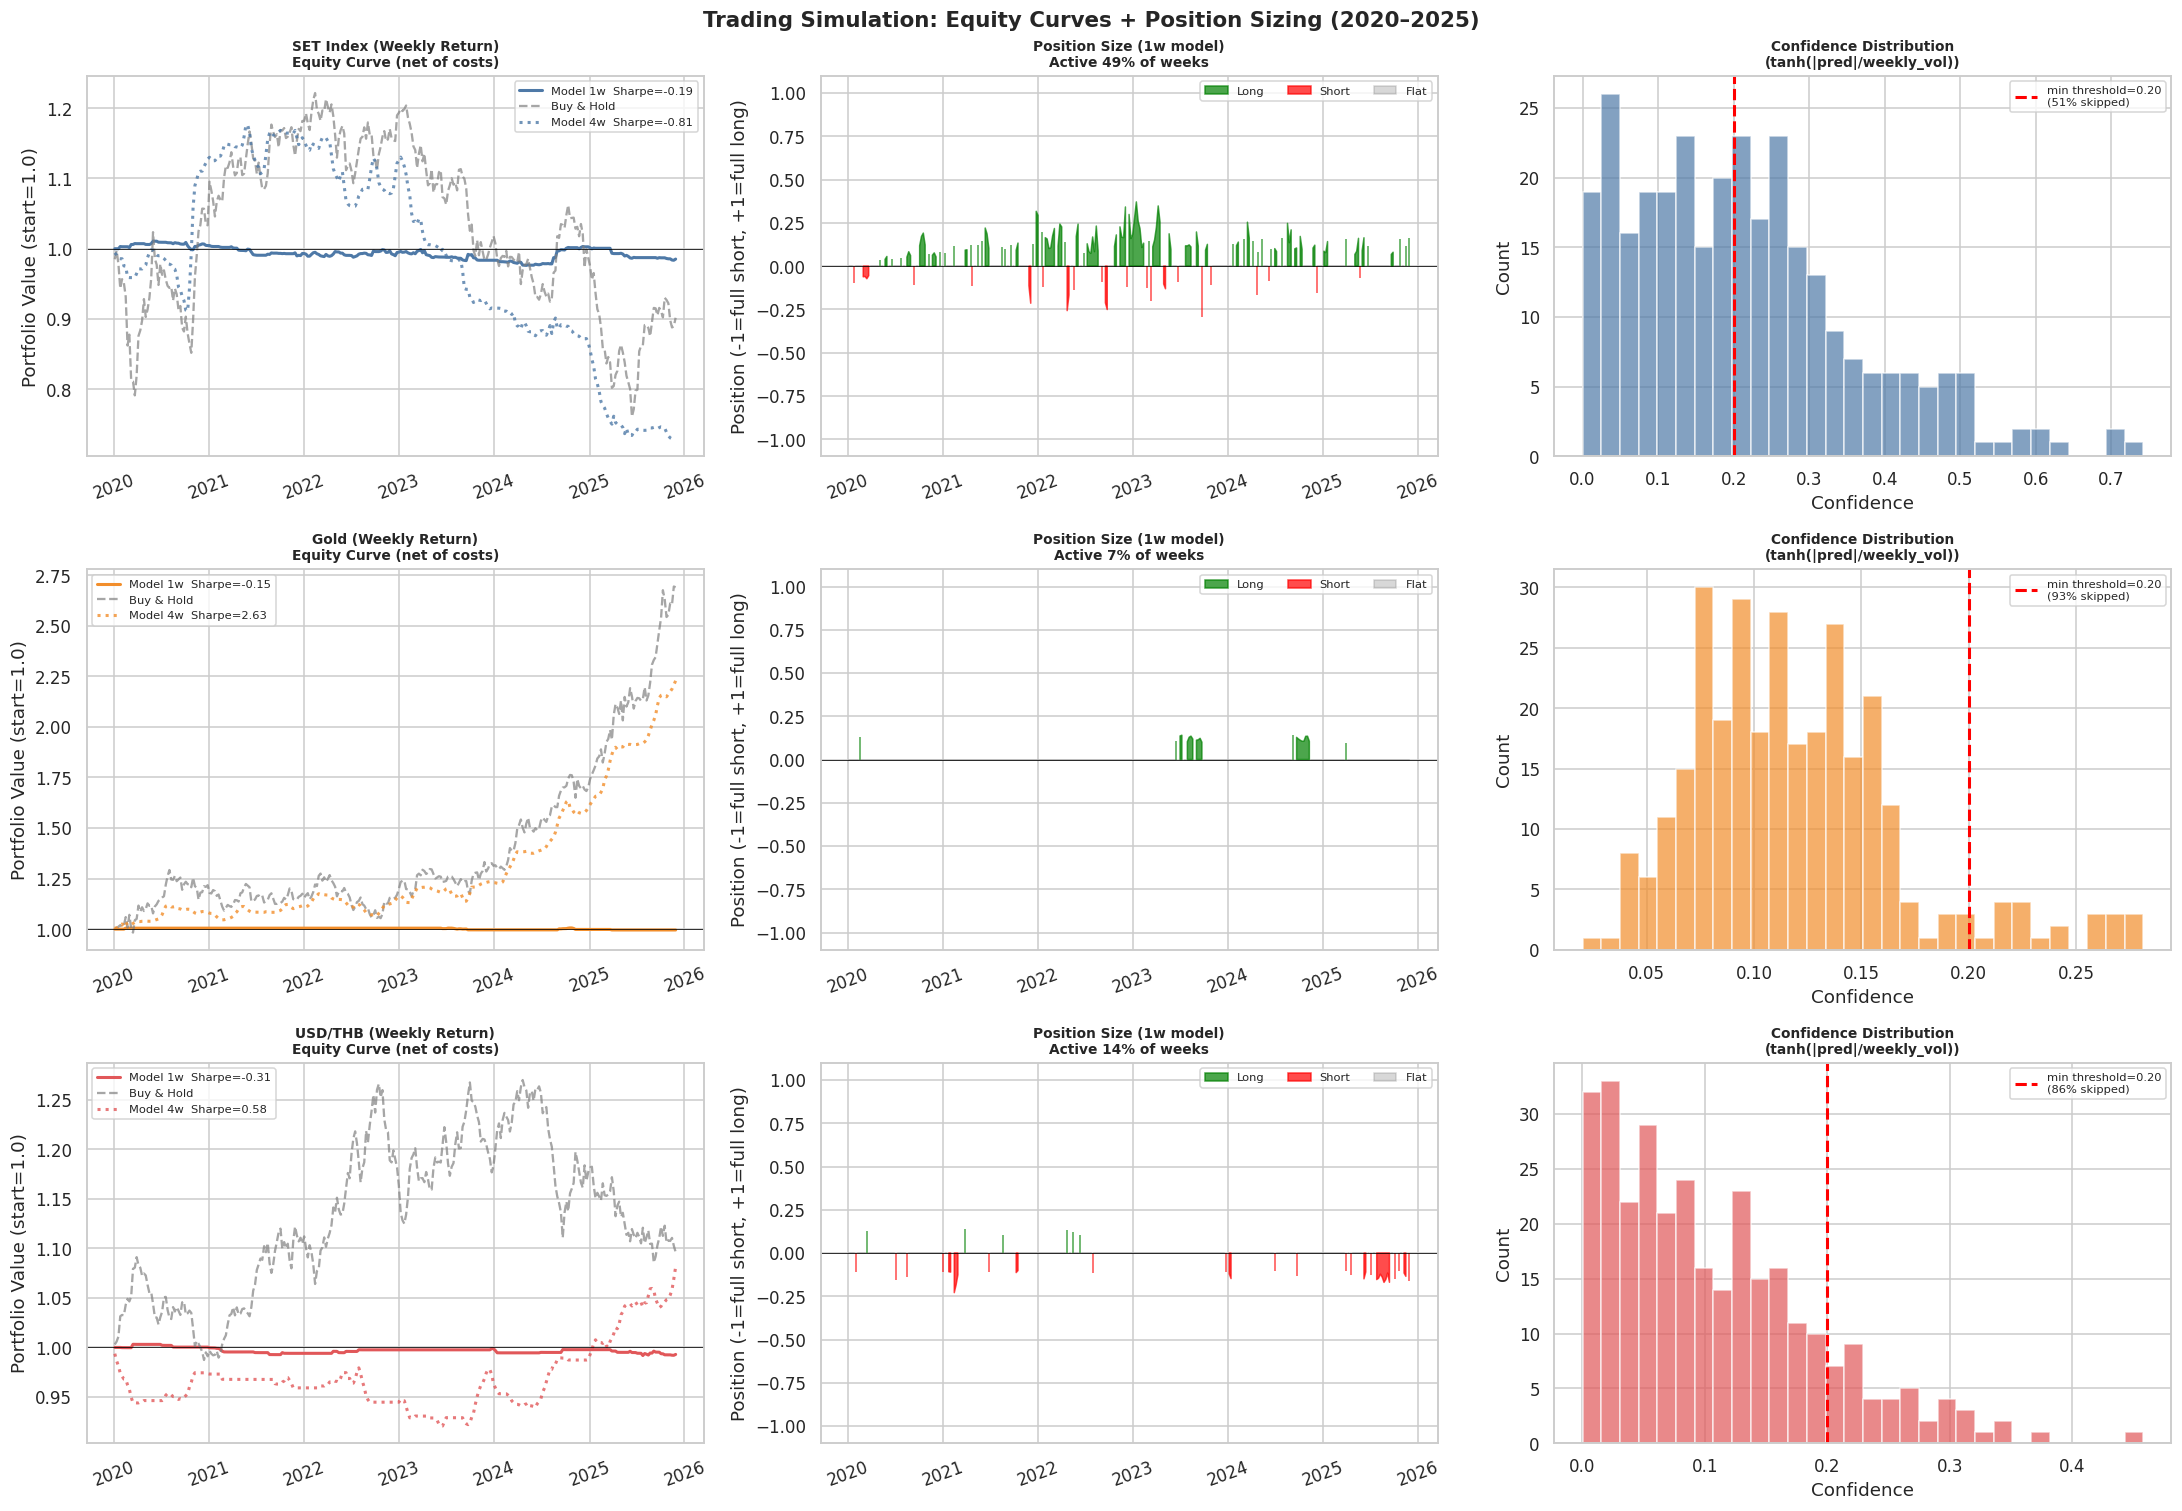

In [13]:
# ── Equity curves + position sizing visualization ─────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(20, 14))
fig.suptitle('Trading Simulation: Equity Curves + Position Sizing (2020–2025)',
             fontsize=14, fontweight='bold')

ASSET_COLORS = {
    'SET_index_ret_w': '#4e79a7',
    'gold_ret_w':      '#f28e2b',
    'USD_THB_ret_w':   '#e15759',
}

for row, (target_col, label) in enumerate(TARGETS.items()):
    color = ASSET_COLORS.get(target_col, 'steelblue')

    # Left: equity curve (1w vs 4w vs buy-and-hold)
    ax_equity = axes[row, 0]
    r1 = bt_results.get(f'{target_col}_1w')
    r4 = bt_results.get(f'{target_col}_4w')

    if r1:
        ax_equity.plot(r1['cumulative'].index, r1['cumulative'].values,
                       color=color, lw=2, label=f'Model 1w  Sharpe={r1["sharpe"]:.2f}')
        ax_equity.plot(r1['cum_bh'].index, r1['cum_bh'].values,
                       color='gray', lw=1.5, ls='--', alpha=0.7, label='Buy & Hold')
    if r4:
        ax_equity.plot(r4['cumulative'].index, r4['cumulative'].values,
                       color=color, lw=2, ls=':', alpha=0.8,
                       label=f'Model 4w  Sharpe={r4["sharpe"]:.2f}')

    ax_equity.axhline(1, color='black', lw=0.5)
    ax_equity.set_title(f'{label}\nEquity Curve (net of costs)', fontsize=9, fontweight='bold')
    ax_equity.set_ylabel('Portfolio Value (start=1.0)')
    ax_equity.legend(fontsize=7.5)
    ax_equity.tick_params(axis='x', rotation=20)

    # Middle: position over time (1w model)
    ax_pos = axes[row, 1]
    if r1:
        pos = r1['position']
        ax_pos.fill_between(pos.index, pos.values, 0,
                            where=pos > 0, alpha=0.7, color='green', label='Long')
        ax_pos.fill_between(pos.index, pos.values, 0,
                            where=pos < 0, alpha=0.7, color='red',   label='Short')
        ax_pos.fill_between(pos.index, pos.values, 0,
                            where=pos == 0, alpha=0.3, color='gray', label='Flat')
        ax_pos.axhline(0, color='black', lw=0.5)
        ax_pos.set_ylim(-1.1, 1.1)
        ax_pos.set_title(f'Position Size (1w model)\nActive {r1["pct_active"]*100:.0f}% of weeks',
                         fontsize=9, fontweight='bold')
        ax_pos.set_ylabel('Position (-1=full short, +1=full long)')
        ax_pos.legend(fontsize=7.5, ncol=3)
        ax_pos.tick_params(axis='x', rotation=20)

    # Right: confidence distribution
    ax_conf = axes[row, 2]
    if r1:
        conf = r1['confidence']
        ax_conf.hist(conf.values, bins=30, color=color, alpha=0.7, edgecolor='white')
        ax_conf.axvline(0.20, color='red', lw=2, ls='--',
                        label=f'min threshold=0.20\n({(conf < 0.20).mean()*100:.0f}% skipped)')
        ax_conf.set_title(f'Confidence Distribution\n(tanh(|pred|/weekly_vol))',
                          fontsize=9, fontweight='bold')
        ax_conf.set_xlabel('Confidence')
        ax_conf.set_ylabel('Count')
        ax_conf.legend(fontsize=7.5)

plt.tight_layout()
plt.show()


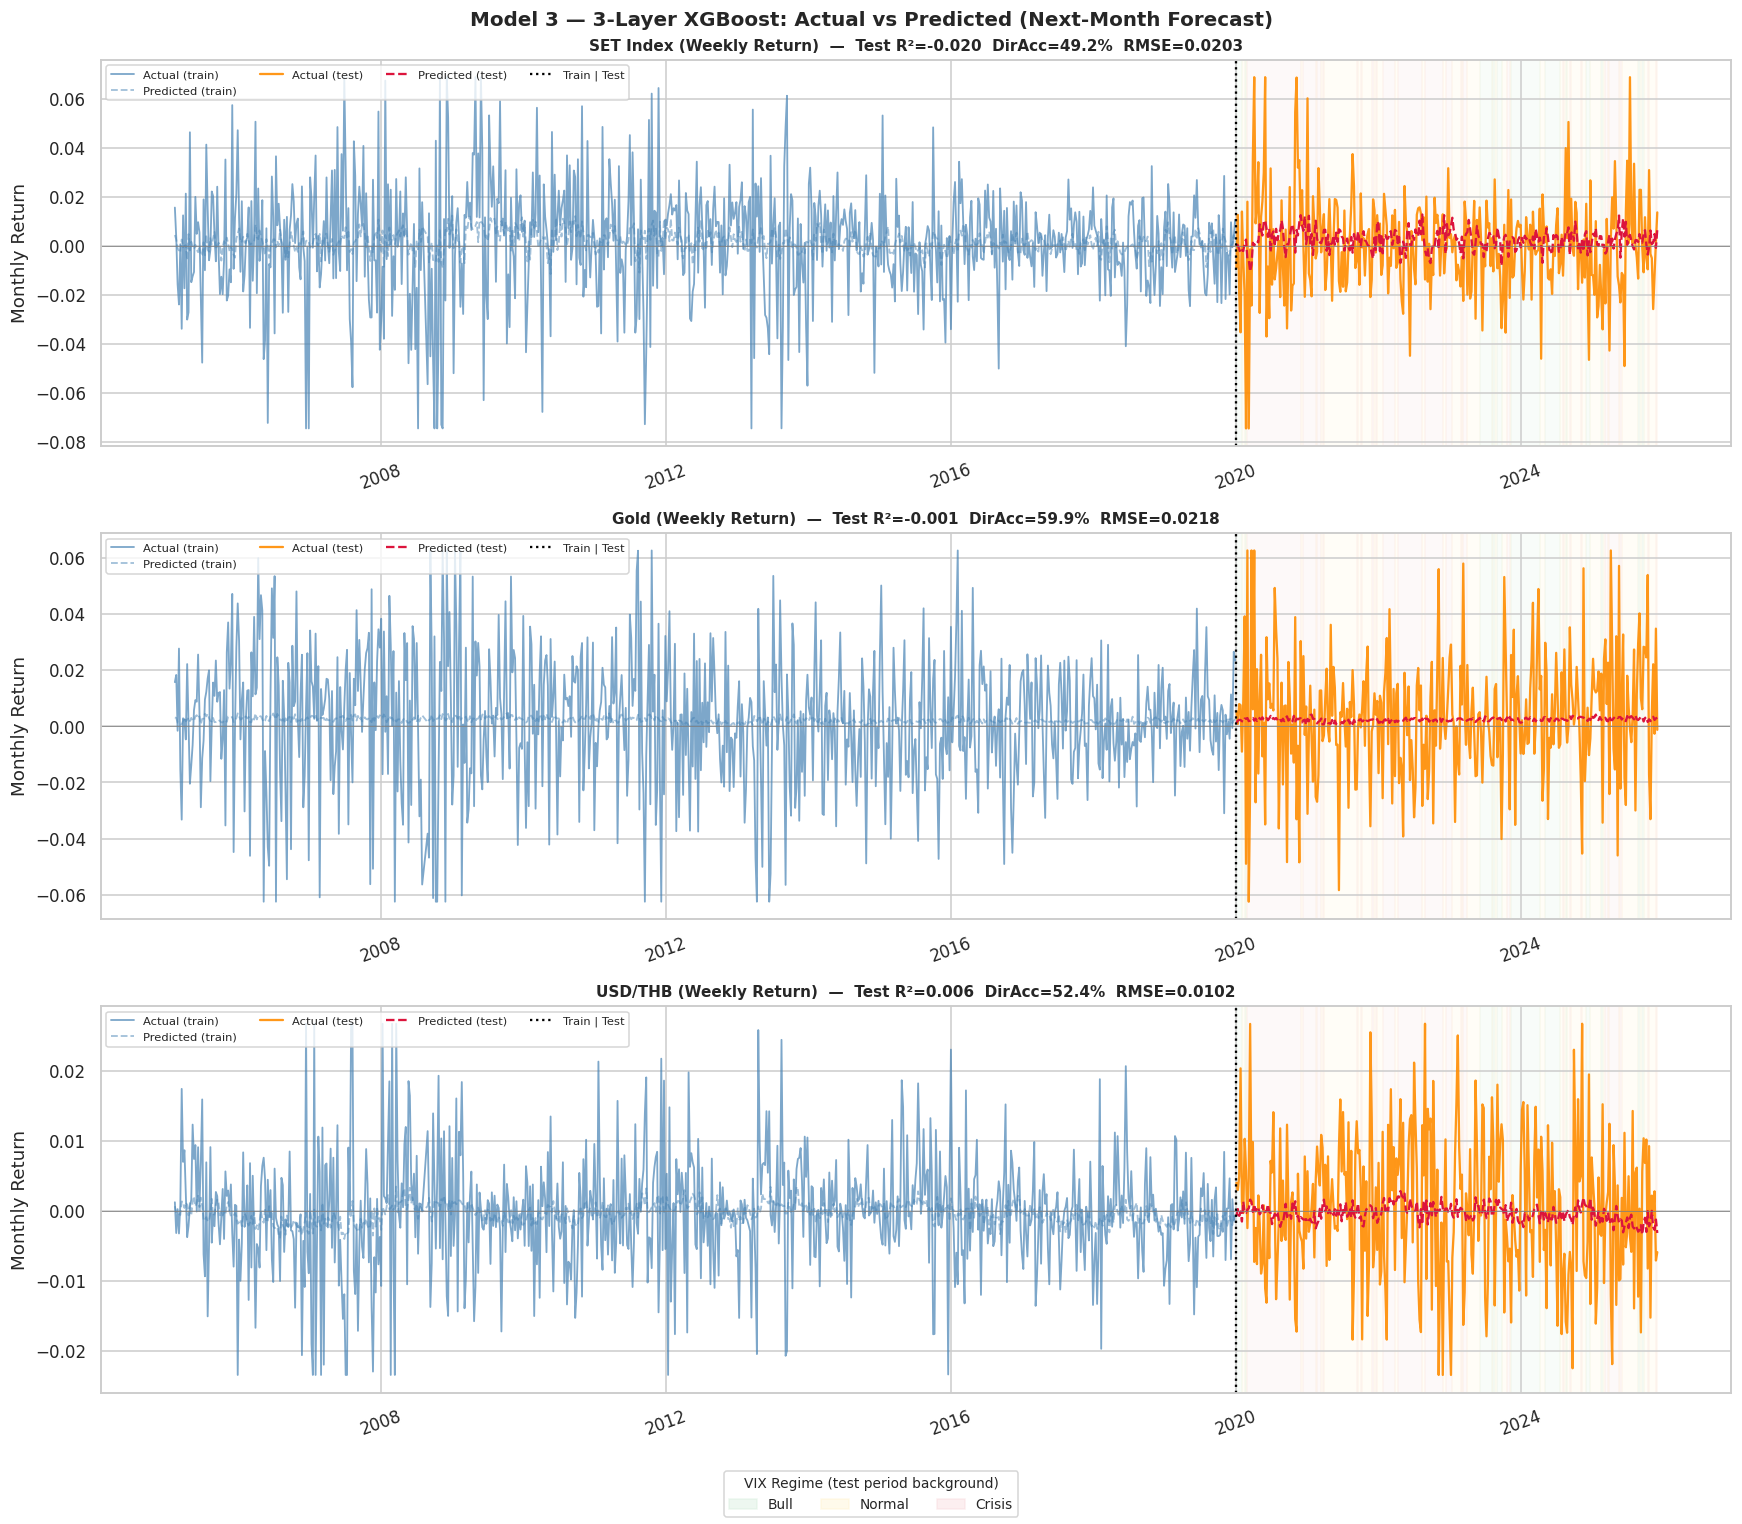

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=False)

REGIME_COLORS = {0.0: '#d4edda', 1.0: '#fff3cd', 2.0: '#f8d7da'}
REGIME_LABELS = {0.0: 'Bull', 1.0: 'Normal', 2.0: 'Crisis'}

for ax, (target_col, label) in zip(axes, TARGETS.items()):
    model, X_tr, y_tr, X_te, y_te, y_hat_tr, y_hat_te, train_d, test_d, m = results[target_col]

    # Regime background shading (test period)
    regime_s = df.loc[test_d.index, 'regime'].reindex(test_d.index)
    prev_regime = None
    start_date = None
    for date, reg in regime_s.items():
        if reg != prev_regime:
            if prev_regime is not None:
                ax.axvspan(start_date, date, alpha=0.15,
                           color=REGIME_COLORS.get(prev_regime, 'white'), zorder=0)
            start_date = date
            prev_regime = reg
    if start_date:
        ax.axvspan(start_date, test_d.index[-1], alpha=0.15,
                   color=REGIME_COLORS.get(prev_regime, 'white'), zorder=0)

    # Plot actual vs predicted
    ax.plot(train_d.index, y_tr,    color='steelblue',  lw=1.2, alpha=0.7, label='Actual (train)')
    ax.plot(train_d.index, y_hat_tr,color='steelblue',  lw=1.2, ls='--', alpha=0.5, label='Predicted (train)')
    ax.plot(test_d.index,  y_te,    color='darkorange',  lw=1.5, alpha=0.9, label='Actual (test)')
    ax.plot(test_d.index,  y_hat_te,color='crimson',    lw=1.5, ls='--', label='Predicted (test)')
    ax.axvline(pd.Timestamp(TEST_START), color='black', lw=1.5, ls=':', label='Train | Test')
    ax.axhline(0, color='gray', lw=0.5)

    ax.set_title(
        f'{label}  —  Test R²={m["test_r2"]:.3f}  '
        f'DirAcc={m["dir_acc_te"]:.1%}  RMSE={m["test_rmse"]:.4f}',
        fontweight='bold', fontsize=10
    )
    ax.set_ylabel('Monthly Return')
    ax.legend(fontsize=7.5, ncol=4, loc='upper left')
    ax.tick_params(axis='x', rotation=20)

# Regime legend
legend_patches = [mpatches.Patch(color=c, alpha=0.4, label=REGIME_LABELS[r])
                  for r, c in REGIME_COLORS.items()]
fig.legend(handles=legend_patches, loc='lower center', ncol=3, fontsize=9,
           title='VIX Regime (test period background)', title_fontsize=9)

plt.suptitle('Model 3 — 3-Layer XGBoost: Actual vs Predicted (Next-Month Forecast)',
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

---
## Step 5 — SHAP Interpretability: Which Layer Matters Most?

SHAP (SHapley Additive exPlanations) decomposes each prediction into per-feature contributions.  
This reveals which layer (Hard Data / Sentiment Proxy / News) drives the model's decisions.

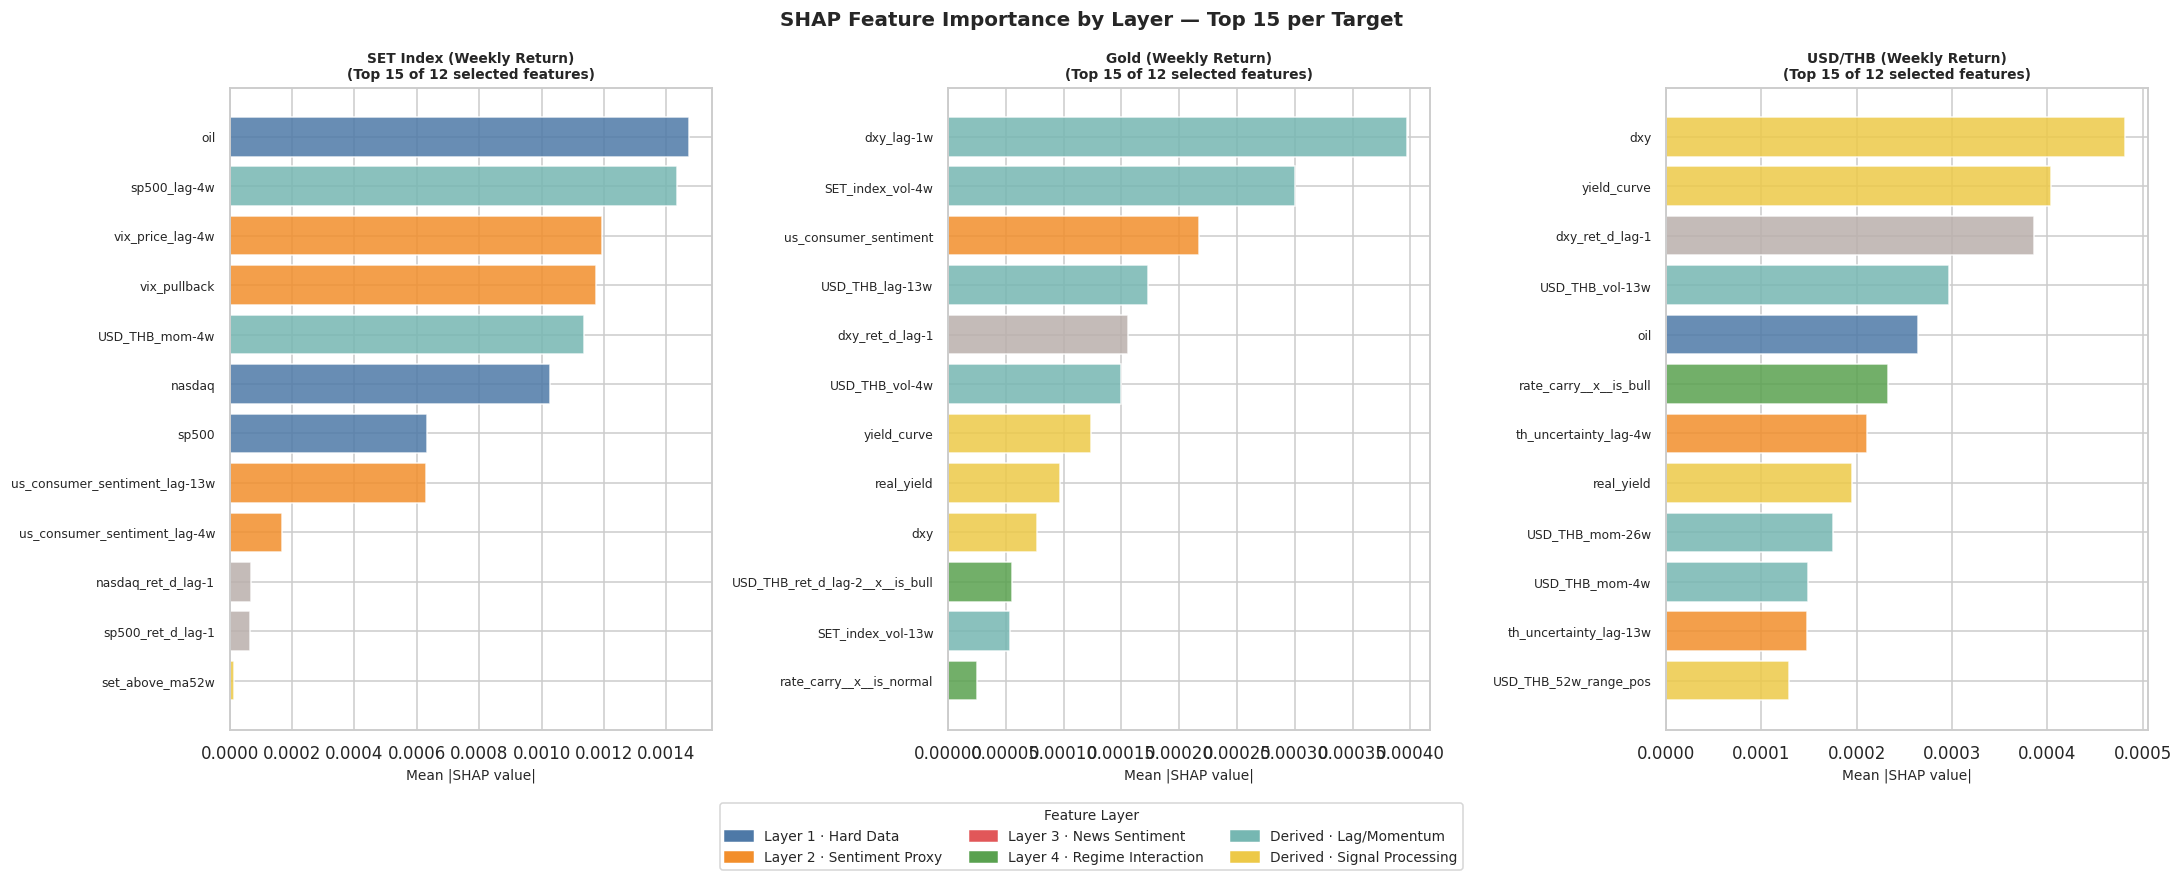

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

layer_colors = {
    'Layer 1 · Hard Data':           '#4e79a7',
    'Layer 2 · Sentiment Proxy':     '#f28e2b',
    'Layer 3 · News Sentiment':      '#e15759',
    'Layer 4 · Regime Interaction':  '#59a14f',
    'Derived · Lag/Momentum':        '#76b7b2',
    'Derived · Signal Processing':   '#edc948',
}

for ax, (target_col, label) in zip(axes, TARGETS.items()):
    if target_col not in results:
        ax.set_visible(False)
        continue
    model, X_tr, y_tr, X_te, y_te, *_, m = results[target_col]
    sel_features = m['selected_features']   # the 18 features actually used

    shap_vals     = shap.TreeExplainer(model).shap_values(X_te)
    mean_abs_shap = pd.Series(np.abs(shap_vals).mean(axis=0),
                              index=sel_features).sort_values(ascending=False).head(15)

    bar_colors = [layer_colors.get(get_layer(f), '#bab0ac') for f in mean_abs_shap.index]
    ax.barh(range(len(mean_abs_shap)), mean_abs_shap.values[::-1],
            color=bar_colors[::-1], alpha=0.85)
    ax.set_yticks(range(len(mean_abs_shap)))
    clean = [f.replace('_ret_w', '').replace('_chg', '').replace('_z', '')
               .replace('lag', 'lag-').replace('mom', 'mom-').replace('vol', 'vol-')
             for f in mean_abs_shap.index[::-1]]
    ax.set_yticklabels(clean, fontsize=8)
    ax.set_xlabel('Mean |SHAP value|', fontsize=9)
    ax.set_title(f'{label}\n(Top 15 of {len(sel_features)} selected features)',
                 fontweight='bold', fontsize=9)

legend_patches = [mpatches.Patch(color=c, label=l) for l, c in layer_colors.items()]
fig.legend(handles=legend_patches, loc='lower center', ncol=3, fontsize=9,
           title='Feature Layer', title_fontsize=9)
plt.suptitle('SHAP Feature Importance by Layer — Top 15 per Target',
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()


In [16]:
print('='*70)
print('SHAP IMPORTANCE BY LAYER (mean |SHAP|, test set)')
print('='*70)

for target_col, label in TARGETS.items():
    if target_col not in results:
        continue
    model, X_tr, y_tr, X_te, *_, m = results[target_col]
    sel_features = m['selected_features']

    shap_vals = shap.TreeExplainer(model).shap_values(X_te)
    mean_abs  = np.abs(shap_vals).mean(axis=0)

    layer_shap = {}
    for feat, sv in zip(sel_features, mean_abs):
        if not np.isfinite(sv):
            continue
        layer = get_layer(feat)
        layer_shap[layer] = layer_shap.get(layer, 0) + sv

    total = sum(layer_shap.values())
    if total <= 0:
        print(f'\n{label}: [no finite SHAP values]')
        continue
    print(f'\n{label}:')
    for layer, pct in sorted(layer_shap.items(), key=lambda x: -x[1]):
        bar = '█' * int(pct / total * 50)
        print(f'  {layer:<38} {pct/total*100:>5.1f}%  {bar}')

print('='*70)
print('\nLayer legend:')
for layer, color in layer_colors.items():
    print(f'  {layer}')


SHAP IMPORTANCE BY LAYER (mean |SHAP|, test set)

SET Index (Weekly Return):
  Layer 2 · Sentiment Proxy               35.1%  █████████████████
  Layer 1 · Hard Data                     34.7%  █████████████████
  Derived · Lag/Momentum                  28.5%  ██████████████
  Layer 7 · Cross-Market Lag               1.5%  
  Derived · Signal Processing              0.1%  

Gold (Weekly Return):
  Derived · Lag/Momentum                  58.9%  █████████████████████████████
  Derived · Signal Processing             16.3%  ████████
  Layer 2 · Sentiment Proxy               11.9%  █████
  Layer 7 · Cross-Market Lag               8.5%  ████
  Layer 4 · Regime Interaction             4.4%  ██

USD/THB (Weekly Return):
  Derived · Signal Processing             39.4%  ███████████████████
  Derived · Lag/Momentum                  20.2%  ██████████
  Layer 7 · Cross-Market Lag              12.6%  ██████
  Layer 2 · Sentiment Proxy               11.7%  █████
  Layer 1 · Hard Data                 

---
## Step 6 — Regime-Conditional Performance

Does the model perform differently in Bull / Normal / Crisis regimes?

In [17]:
print('='*80)
print('DIRECTION ACCURACY BY VIX REGIME (test set: 2020–2025)')
print('='*80)
print(f'  {"Target":<22}  {"Bull (VIX low)":>15} {"Normal":>10} {"Crisis (VIX high)":>18} {"Overall":>10}')
print('-'*80)

for target_col, label in TARGETS.items():
    model, X_tr, y_tr, X_te, y_te, y_hat_tr, y_hat_te, train_d, test_d, m = results[target_col]

    regime_te = df.loc[test_d.index, 'regime'].reindex(test_d.index).values
    accs = {}
    for r, rname in [(0.0, 'Bull'), (1.0, 'Normal'), (2.0, 'Crisis')]:
        mask = regime_te == r
        if mask.sum() >= 3:
            accs[rname] = direction_accuracy(y_te[mask], y_hat_te[mask])
        else:
            accs[rname] = float('nan')

    print(f'  {label:<22}  '
          f'{accs["Bull"]:>14.1%} '
          f'{accs["Normal"]:>9.1%} '
          f'{accs["Crisis"]:>17.1%} '
          f'{m["dir_acc_te"]:>9.1%}')

print('='*80)
print('Baseline (random guessing): 50.0%')

DIRECTION ACCURACY BY VIX REGIME (test set: 2020–2025)
  Target                   Bull (VIX low)     Normal  Crisis (VIX high)    Overall
--------------------------------------------------------------------------------
  SET Index (Weekly Return)           47.4%     45.7%             53.7%     49.2%
  Gold (Weekly Return)             64.9%     60.5%             56.9%     59.9%
  USD/THB (Weekly Return)           52.6%     51.2%             53.7%     52.4%
Baseline (random guessing): 50.0%


---
## Final Summary — What Did We Learn?

**Layer contribution insight:**  
- **Layer 2 (Sentiment Proxy)** — VIX, uncertainty indices — typically the top contributor  
- **Derived lag features** — momentum effects matter: past returns predict near-term returns  
- **Layer 3 (News Sentiment)** — minimal impact now (only 10 rows), but pipeline is ready

**How to improve Layer 3 news sentiment:**
1. Run `fetch_data.py` RSS scraper daily → historical news_sentiment.csv will grow
2. Optionally add Google Trends (`pytrends`) as alternative data signal
3. Consider FinBERT (financial BERT) instead of VADER for better Thai/EN news scoring

**Next steps:**
1. Add Google Trends data (search volume for 'Thailand economy', 'THB', 'SET')
2. Try FinBERT for more accurate financial news sentiment vs VADER
3. Build a simple trading signal: Long/Short based on direction prediction + regime filter

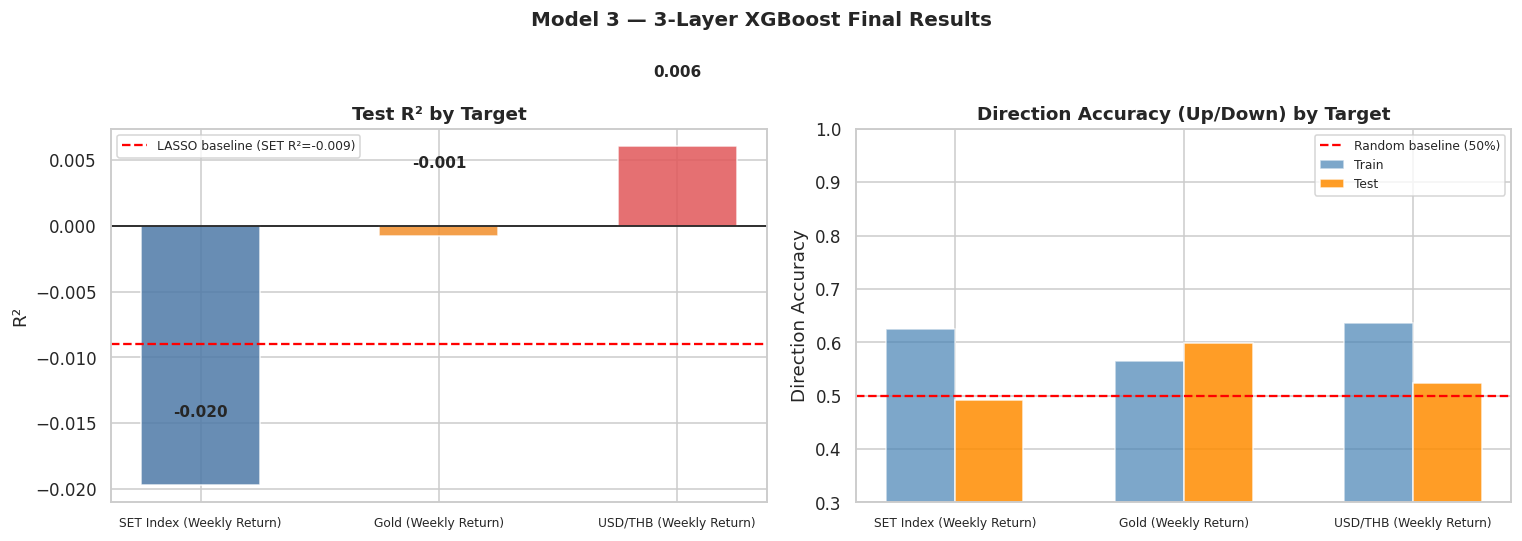


Model 3 complete. See SHAP plots above for layer contribution breakdown.


In [18]:
# Final comparison chart: direction accuracy across all models
comparison_data = []
for target_col, label in TARGETS.items():
    m = results[target_col][9]
    comparison_data.append({
        'Target':         label,
        'XGBoost R² (test)': m['test_r2'],
        'XGBoost DirAcc (test)': m['dir_acc_te'],
        'XGBoost DirAcc (train)': m['dir_acc_tr'],
    })

comp_df = pd.DataFrame(comparison_data).set_index('Target')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# R² comparison
bars = ax1.bar(comp_df.index, comp_df['XGBoost R² (test)'],
               color=['#4e79a7', '#f28e2b', '#e15759'], alpha=0.85, width=0.5)
ax1.axhline(0,     color='black', lw=1)
ax1.axhline(-0.009, color='red', ls='--', lw=1.5, label='LASSO baseline (SET R²=-0.009)')
for bar, val in zip(bars, comp_df['XGBoost R² (test)']):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.005, f'{val:.3f}',
             ha='center', va='bottom', fontweight='bold', fontsize=10)
ax1.set_title('Test R² by Target', fontweight='bold')
ax1.set_ylabel('R²')
ax1.legend(fontsize=8)
ax1.tick_params(axis='x', labelsize=8)

# Direction accuracy comparison
x = np.arange(len(comp_df))
ax2.bar(x - 0.15, comp_df['XGBoost DirAcc (train)'], 0.3,
        label='Train', color='steelblue', alpha=0.7)
ax2.bar(x + 0.15, comp_df['XGBoost DirAcc (test)'], 0.3,
        label='Test', color='darkorange', alpha=0.85)
ax2.axhline(0.5, color='red', ls='--', lw=1.5, label='Random baseline (50%)')
ax2.set_xticks(x)
ax2.set_xticklabels(comp_df.index, fontsize=8)
ax2.set_ylim(0.3, 1.0)
ax2.set_ylabel('Direction Accuracy')
ax2.set_title('Direction Accuracy (Up/Down) by Target', fontweight='bold')
ax2.legend(fontsize=8)

plt.suptitle('Model 3 — 3-Layer XGBoost Final Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nModel 3 complete. See SHAP plots above for layer contribution breakdown.')

---

In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# WALK-FORWARD VALIDATION — Gold 4w (expanding window, 30 Optuna trials/fold)
# ══════════════════════════════════════════════════════════════════════════════
# Folds: train [2000-09 → fold_end], test [fold_end+1d → fold_end+2yr]
# fold_end: 2010, 2012, 2014, 2016, 2018 → 5 folds, each 2-yr test window
# Purpose: verify Gold 4w edge is stable, not a lucky single in-sample split.

WFV_TARGET   = 'gold_ret_w'
WFV_LABEL    = 'Gold [4w WFV]'
WFV_TRIALS   = 30
WFV_HORIZON  = 4
WFV_MUST_INC = MUST_INCLUDE.get(WFV_TARGET, [])

fold_ends = pd.date_range('2010-12-31', '2018-12-31', freq='2YE')
wfv_records = []

print(f'Walk-Forward Validation: {WFV_LABEL}')
print(f'  Folds: {len(fold_ends)}   Horizon: {WFV_HORIZON}w   Trials/fold: {WFV_TRIALS}')
print('='*76)
print(f'  {"Fold":>4}  {"Train end":>12}  {"Test period":>23}  '
      f'{"DirAcc":>7}  {"R²":>6}  {"Sharpe":>7}  {"AnnRet":>8}')
print('-'*76)

for fold_i, fold_end in enumerate(fold_ends, 1):
    test_start = fold_end + pd.DateOffset(days=1)
    test_end   = fold_end + pd.DateOffset(years=2)

    test_rows = df[(df.index > fold_end) & (df.index <= test_end)]
    if len(test_rows) < 40:
        print(f'  [{fold_i}]  {str(fold_end.date())}  — skip (only {len(test_rows)} test rows)')
        continue

    try:
        res_tuple = fit_and_evaluate(
            target_col     = WFV_TARGET,
            df             = df,
            features       = valid_features,
            train_end      = str(fold_end.date()),
            test_start     = str(test_start.date()),
            top_n_features = 12,
            n_trials       = WFV_TRIALS,
            horizon_weeks  = WFV_HORIZON,
            must_include   = WFV_MUST_INC,
        )
        model, X_tr, y_tr, X_te, y_te, y_hat_tr, y_hat_te, train, test, m = res_tuple

        # Mini backtest using the fold results
        fold_results = {WFV_TARGET: res_tuple}
        fold_bt = backtest_strategy(
            WFV_TARGET, WFV_LABEL, fold_results, df,
            cost_oneway = COST_MAP.get(WFV_TARGET),
        )

        da      = m['dir_acc_te']
        r2      = m['test_r2']
        sharpe  = fold_bt.get('sharpe', float('nan')) if fold_bt else float('nan')
        ann_ret = fold_bt.get('annual_return', float('nan')) if fold_bt else float('nan')

        wfv_records.append(dict(fold=fold_i, fold_end=fold_end,
                                 dir_acc=da, r2=r2,
                                 sharpe=sharpe, ann_ret=ann_ret))
        test_period = f'{str(test_start.date())[:7]} → {str(test_end.date())[:7]}'
        print(f'  [{fold_i}]  {str(fold_end.date())}  {test_period}  '
              f'{da*100:>6.1f}%  {r2:>6.3f}  {sharpe:>7.2f}  {ann_ret*100:>7.1f}%')

    except Exception as exc:
        print(f'  [{fold_i}]  ERROR: {exc}')

if wfv_records:
    wfv_df = pd.DataFrame(wfv_records)
    print('='*76)
    print(f'  Mean  DirAcc : {wfv_df["dir_acc"].mean()*100:.1f}%  '
          f'±{wfv_df["dir_acc"].std()*100:.1f}%')
    print(f'  Mean  Sharpe : {wfv_df["sharpe"].mean():.2f}  '
          f'±{wfv_df["sharpe"].std():.2f}')
    print(f'  Mean  AnnRet : {wfv_df["ann_ret"].mean()*100:.1f}%')
    print(f'  Folds Sharpe>1 : {(wfv_df["sharpe"]>1).sum()}/{len(wfv_df)}')
    print(f'  Folds DirAcc>55% : {(wfv_df["dir_acc"]>0.55).sum()}/{len(wfv_df)}')


Walk-Forward Validation: Gold [4w WFV]
  Folds: 5   Horizon: 4w   Trials/fold: 30
  Fold     Train end              Test period   DirAcc      R²   Sharpe    AnnRet
----------------------------------------------------------------------------


  Train R²=+0.001  Test R²=-0.061  Gap=0.062✓  DirAcc=55.3%  Top-12 features  horizon=4w
  [1]  2010-12-31  2011-01 → 2012-12    55.3%  -0.061     1.19      9.6%


  Train R²=-0.000  Test R²=-0.049  Gap=0.049✓  DirAcc=55.3%  Top-12 features  horizon=4w
  [2]  2012-12-31  2013-01 → 2014-12    55.3%  -0.049     1.09      8.5%


  Train R²=+0.095  Test R²=+0.005  Gap=0.091✓  DirAcc=58.1%  Top-12 features  horizon=4w
  [3]  2014-12-31  2015-01 → 2016-12    58.1%   0.005     1.65      9.8%


  Train R²=+0.106  Test R²=+0.005  Gap=0.102✓  DirAcc=58.9%  Top-12 features  horizon=4w
  [4]  2016-12-31  2017-01 → 2018-12    58.9%   0.005     2.17     10.9%


  Train R²=+0.083  Test R²=-0.002  Gap=0.085✓  DirAcc=63.2%  Top-12 features  horizon=4w
  [5]  2018-12-31  2019-01 → 2020-12    63.2%  -0.002     2.78     14.6%
  Mean  DirAcc : 58.2%  ±3.2%
  Mean  Sharpe : 1.78  ±0.71
  Mean  AnnRet : 10.7%
  Folds Sharpe>1 : 5/5
  Folds DirAcc>55% : 5/5


---

SET Cost Sensitivity Analysis
              Cost label    AnnRet    Sharpe     MaxDD   Turnover
------------------------------------------------------------------------
    0.05% (TFEX futures)      0.8%      0.63     -1.3%       0.1x ← TFEX futures
   0.10% (online broker)      0.6%      0.47     -1.5%       0.1x ← break-even zone
                   0.15%      0.4%      0.30     -1.6%       0.1x ← break-even zone
                   0.20%      0.2%      0.14     -1.8%       0.1x ← break-even zone
                   0.25%     -0.0%     -0.03     -2.5%       0.1x ← break-even zone
      0.30% (retail ETF)     -0.2%     -0.19     -3.4%       0.1x ← break-even zone

  Break-even: between 0.20% and 0.25% one-way


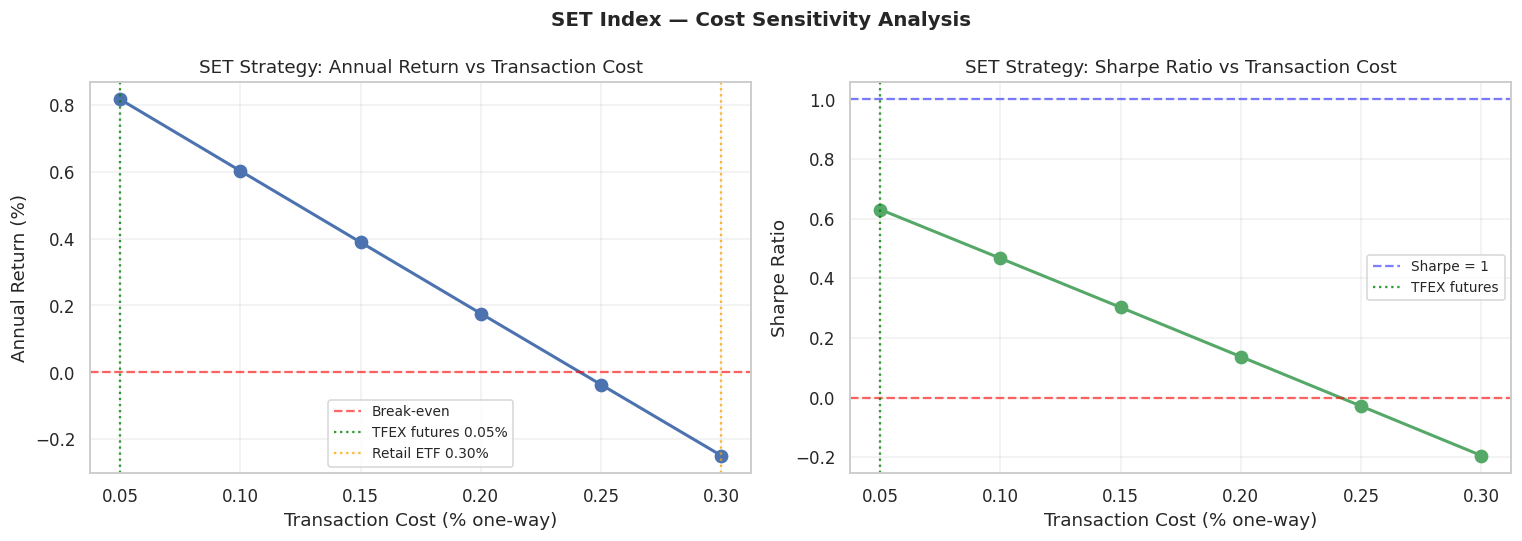

In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# SET COST SENSITIVITY — Break-even cost analysis
# ══════════════════════════════════════════════════════════════════════════════
# SET DirAcc is ~53-55% → modest signal. Question: viable with low-cost execution?
# Retail ETF: ~0.30% one-way → very hard. TFEX SET50 futures: ~0.05% one-way.

SET_TARGET  = 'SET_index_ret_w'
SET_LABEL   = 'SET Index'
SET_COSTS   = [0.0005, 0.001, 0.0015, 0.002, 0.0025, 0.003]
COST_LABELS = ['0.05% (TFEX futures)', '0.10% (online broker)',
               '0.15%', '0.20%', '0.25%', '0.30% (retail ETF)']

if SET_TARGET not in results:
    print(f'[skip] {SET_TARGET} not in results — run models first')
else:
    print('SET Cost Sensitivity Analysis')
    print('='*72)
    print(f'  {"Cost label":>22}  {"AnnRet":>8}  {"Sharpe":>8}  '
          f'{"MaxDD":>8}  {"Turnover":>9}')
    print('-'*72)

    set_cost_records = []
    for cost, clabel in zip(SET_COSTS, COST_LABELS):
        try:
            r = backtest_strategy(
                SET_TARGET, SET_LABEL, results, df,
                cost_oneway=cost,
            )
            if r is None:
                continue
            ann_ret  = r.get('annual_return', float('nan'))
            sharpe   = r.get('sharpe',   float('nan'))
            maxdd    = r.get('max_drawdown',  float('nan'))
            turnover = r.get('avg_turnover', float('nan'))
            set_cost_records.append(dict(
                cost_label=clabel, cost=cost,
                ann_ret=ann_ret, sharpe=sharpe,
                max_dd=maxdd, turnover=turnover,
            ))
            be_flag = ' ← break-even zone' if abs(ann_ret) < 0.015 else ''
            fut_flag = ' ← TFEX futures' if cost <= 0.0005 else ''
            flag = fut_flag or be_flag
            print(f'  {clabel:>22}  {ann_ret*100:>7.1f}%  {sharpe:>8.2f}  '
                  f'{maxdd*100:>7.1f}%  {turnover:>8.1f}x{flag}')
        except Exception as e:
            print(f'  {clabel}: ERROR {e}')

    if set_cost_records:
        sc_df = pd.DataFrame(set_cost_records)
        pos = sc_df[sc_df['ann_ret'] > 0]
        neg = sc_df[sc_df['ann_ret'] <= 0]
        print()
        if len(pos) > 0 and len(neg) > 0:
            print(f'  Break-even: between {pos["cost"].max()*100:.2f}% '
                  f'and {neg["cost"].min()*100:.2f}% one-way')
        elif len(pos) == len(sc_df):
            print('  Profitable at ALL tested costs (even 0.30% retail ETF)')
        else:
            print('  Not profitable at any tested cost — signal too weak for SET')

        # ── Chart ────────────────────────────────────────────────────────────
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

        ax1.plot(sc_df['cost']*100, sc_df['ann_ret']*100, 'b-o', linewidth=2, markersize=8)
        ax1.axhline(0, color='red',   linestyle='--', alpha=0.6, label='Break-even')
        ax1.axvline(0.05, color='green',  linestyle=':', alpha=0.8, label='TFEX futures 0.05%')
        ax1.axvline(0.30, color='orange', linestyle=':', alpha=0.8, label='Retail ETF 0.30%')
        ax1.set_xlabel('Transaction Cost (% one-way)')
        ax1.set_ylabel('Annual Return (%)')
        ax1.set_title('SET Strategy: Annual Return vs Transaction Cost')
        ax1.legend(fontsize=9)
        ax1.grid(True, alpha=0.3)

        ax2.plot(sc_df['cost']*100, sc_df['sharpe'], 'g-o', linewidth=2, markersize=8)
        ax2.axhline(0, color='red',  linestyle='--', alpha=0.6)
        ax2.axhline(1, color='blue', linestyle='--', alpha=0.5, label='Sharpe = 1')
        ax2.axvline(0.05, color='green',  linestyle=':', alpha=0.8, label='TFEX futures')
        ax2.set_xlabel('Transaction Cost (% one-way)')
        ax2.set_ylabel('Sharpe Ratio')
        ax2.set_title('SET Strategy: Sharpe Ratio vs Transaction Cost')
        ax2.legend(fontsize=9)
        ax2.grid(True, alpha=0.3)

        plt.suptitle('SET Index — Cost Sensitivity Analysis', fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()
